# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/model ml/threat detection"

Mounted at /content/drive
/content/drive/MyDrive/model ml/threat detection


# Import Libraries

In [ ]:
!pip install roboflow
!pip install ultralytics
!pip install -U ipywidgets
!pip install wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
import os
from roboflow import Roboflow
import glob
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Download the Data from Roboflow and Data Exploration

In [ ]:
rf = Roboflow(api_key="") #roboflow api
project = rf.workspace("poke-mstry").project("gun-knife-ymlps")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to gun&knife-1 in yolov8:: 100%|██████████| 15002/15002 [01:52<00:00, 133.41it/s]


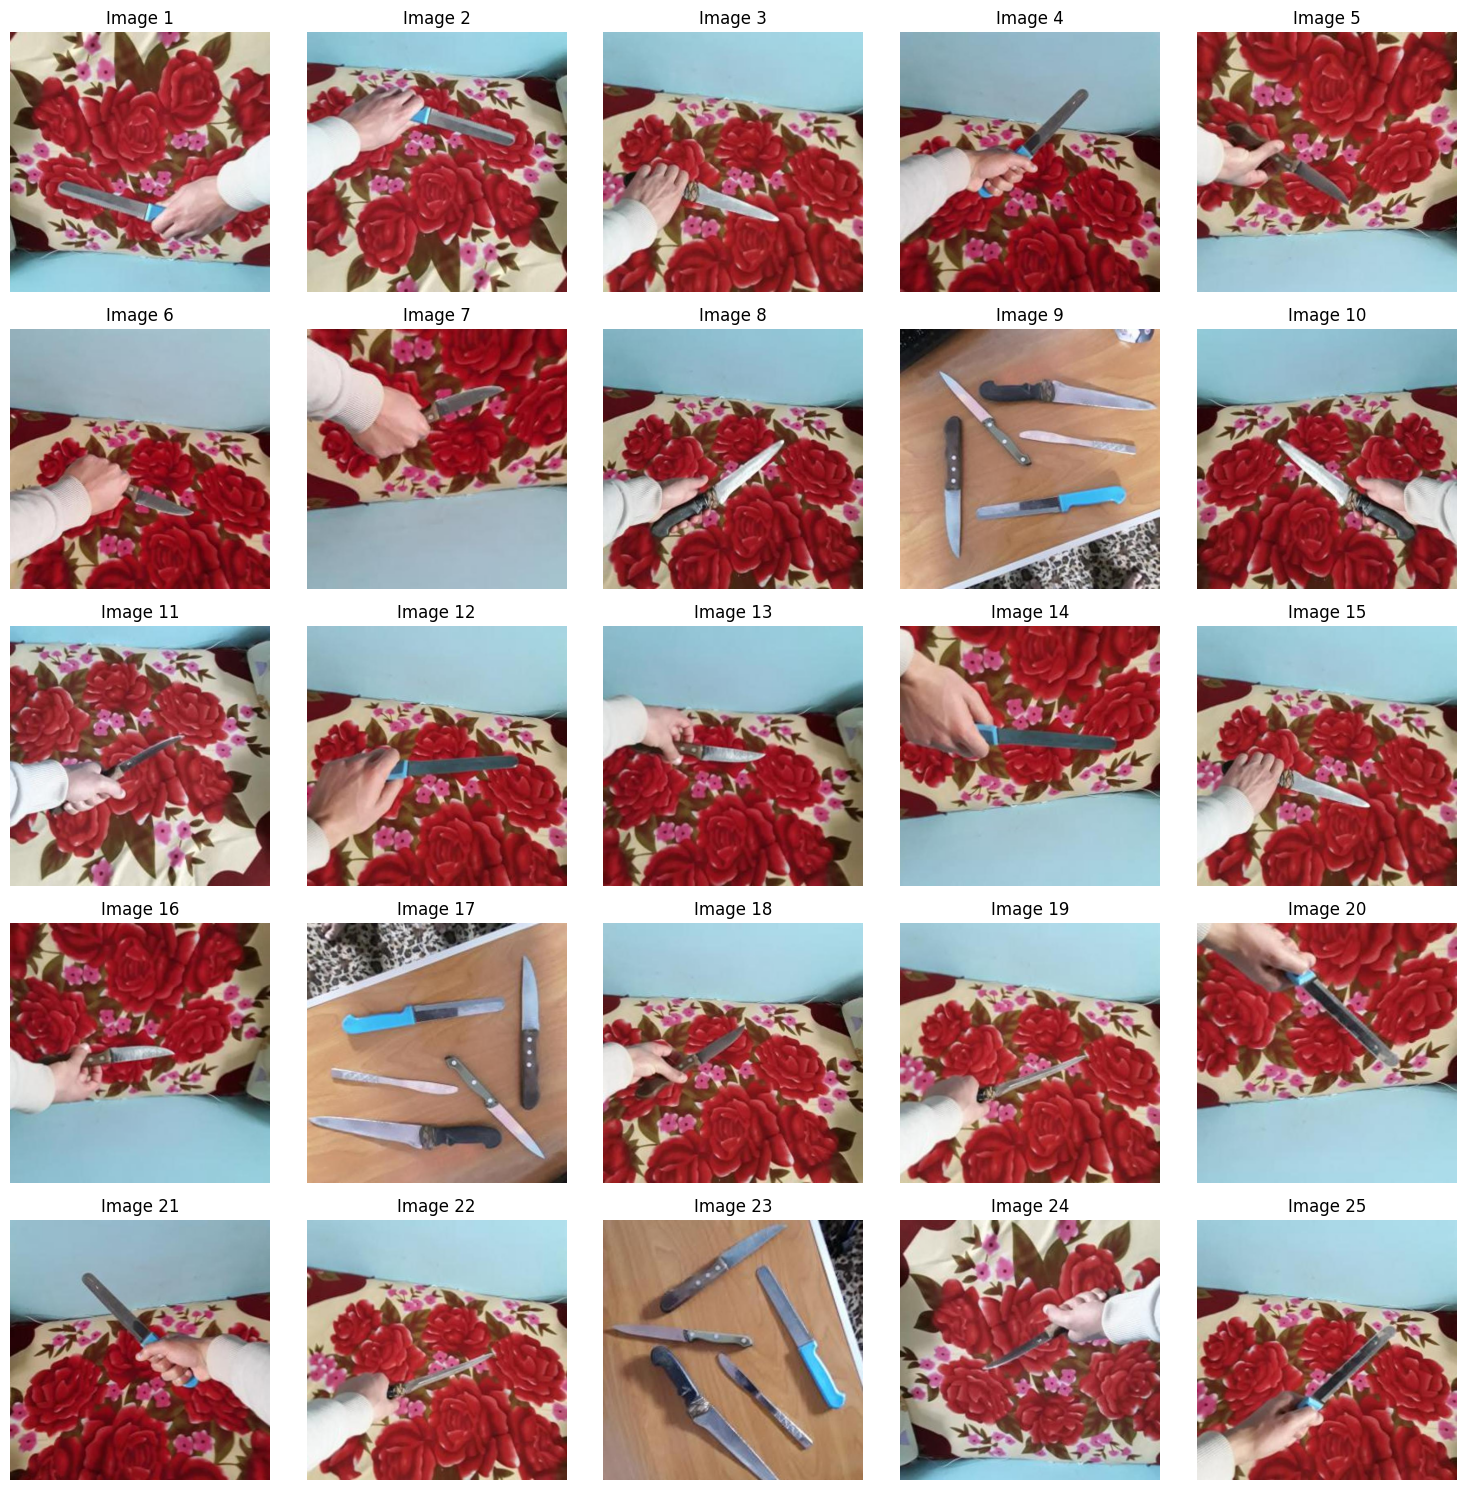

In [ ]:
image_paths = glob.glob("/content/drive/MyDrive/model ml/threat detection/gun&knife-1/train/images/*.jpg")

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
axes = axes.flatten()


for i, (img_path, ax) in enumerate(zip(image_paths[:25], axes)):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')  # Hide axes

    ax.set_title(f"Image {i + 1}", fontsize=12)

plt.tight_layout()
plt.show()

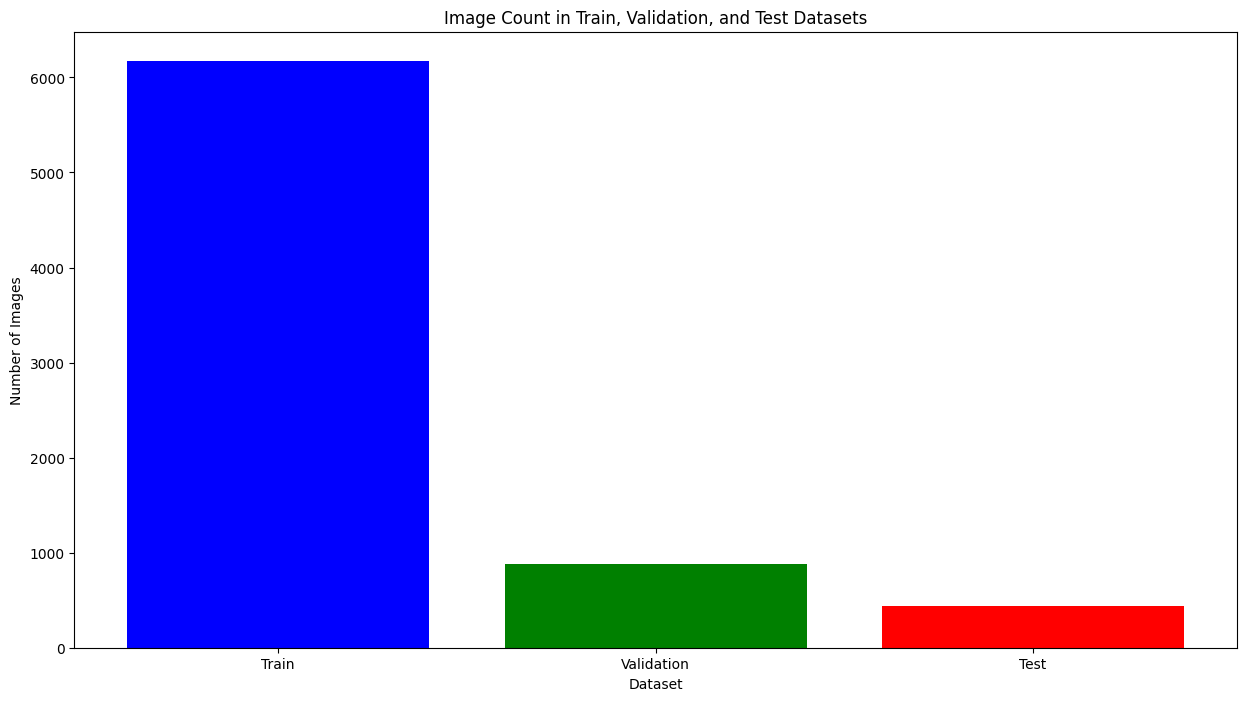

In [ ]:
# Paths to the image directories
train_path = '/content/drive/MyDrive/model ml/threat detection/gun&knife-1/train/images'
valid_path = '/content/drive/MyDrive/model ml/threat detection/gun&knife-1/valid/images'
test_path = '/content/drive/MyDrive/model ml/threat detection/gun&knife-1/test/images'

# Count the number of files in each directory
train_count = len(os.listdir(train_path))
valid_count = len(os.listdir(valid_path))
test_count = len(os.listdir(test_path))

# Create a dictionary to hold the counts
data_counts = {'Train': train_count, 'Validation': valid_count, 'Test': test_count}

# Create a count plot
plt.figure(figsize=(15, 8))
plt.bar(data_counts.keys(), data_counts.values(), color=['blue', 'green', 'red'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Image Count in Train, Validation, and Test Datasets')
plt.show()

# Train the Model

In [ ]:
%cd "/content/drive/MyDrive/model ml/threat detection/ThreatDetection2.3.0"
# Disable Weights & Biases if not needed
os.environ['WANDB_MODE'] = 'dryrun'

/content/drive/MyDrive/model ml/threat detection/ThreatDetection2.3.0


In [ ]:
model = YOLO('yolov8m.pt')
model.train(
    data='/content/drive/MyDrive/model ml/threat detection/gun&knife-1/data.yaml',
    epochs=30,
    imgsz=640,
    optimizer="RAdam",
    batch=8,
    device=0,
    lr0=0.001,
    patience=10,
    pretrained=True,
    augment=True
)

100%|██████████| 49.7M/49.7M [00:00<00:00, 212MB/s]


Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/model ml/threat detection/gun&knife-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=RAdam, overlap_mask=True, patience=10, perspective=

100%|██████████| 755k/755k [00:00<00:00, 21.8MB/s]

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  2   1846272  ultralytics.nn.modules.block.C2f             [576, 384, 2]                 
 19                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384, 384, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  2   4207104  ultralytics.nn.modules.block.C2f             [960, 576, 2]                 
 22        [15, 18, 21]  1   3776854  ultralytics.nn.modules.head.Detect           [2, [192, 384, 576]]          
Model summary: 169 layers, 25,857,478 parameters, 25,857,462 gradients, 79.1 GFLOPs

Transferred 469/475 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


...

                   all        882       1003      0.906      0.847      0.926      0.704



30 epochs completed in 2.509 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:27<00:00,  2.02it/s]


                   all        882       1003      0.874      0.866      0.932      0.718
                 knife        449        502      0.884      0.884      0.942      0.678
                pistol        425        501      0.864      0.848      0.922      0.759
Speed: 0.2ms preprocess, 24.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7faef6b4c590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# Training Results

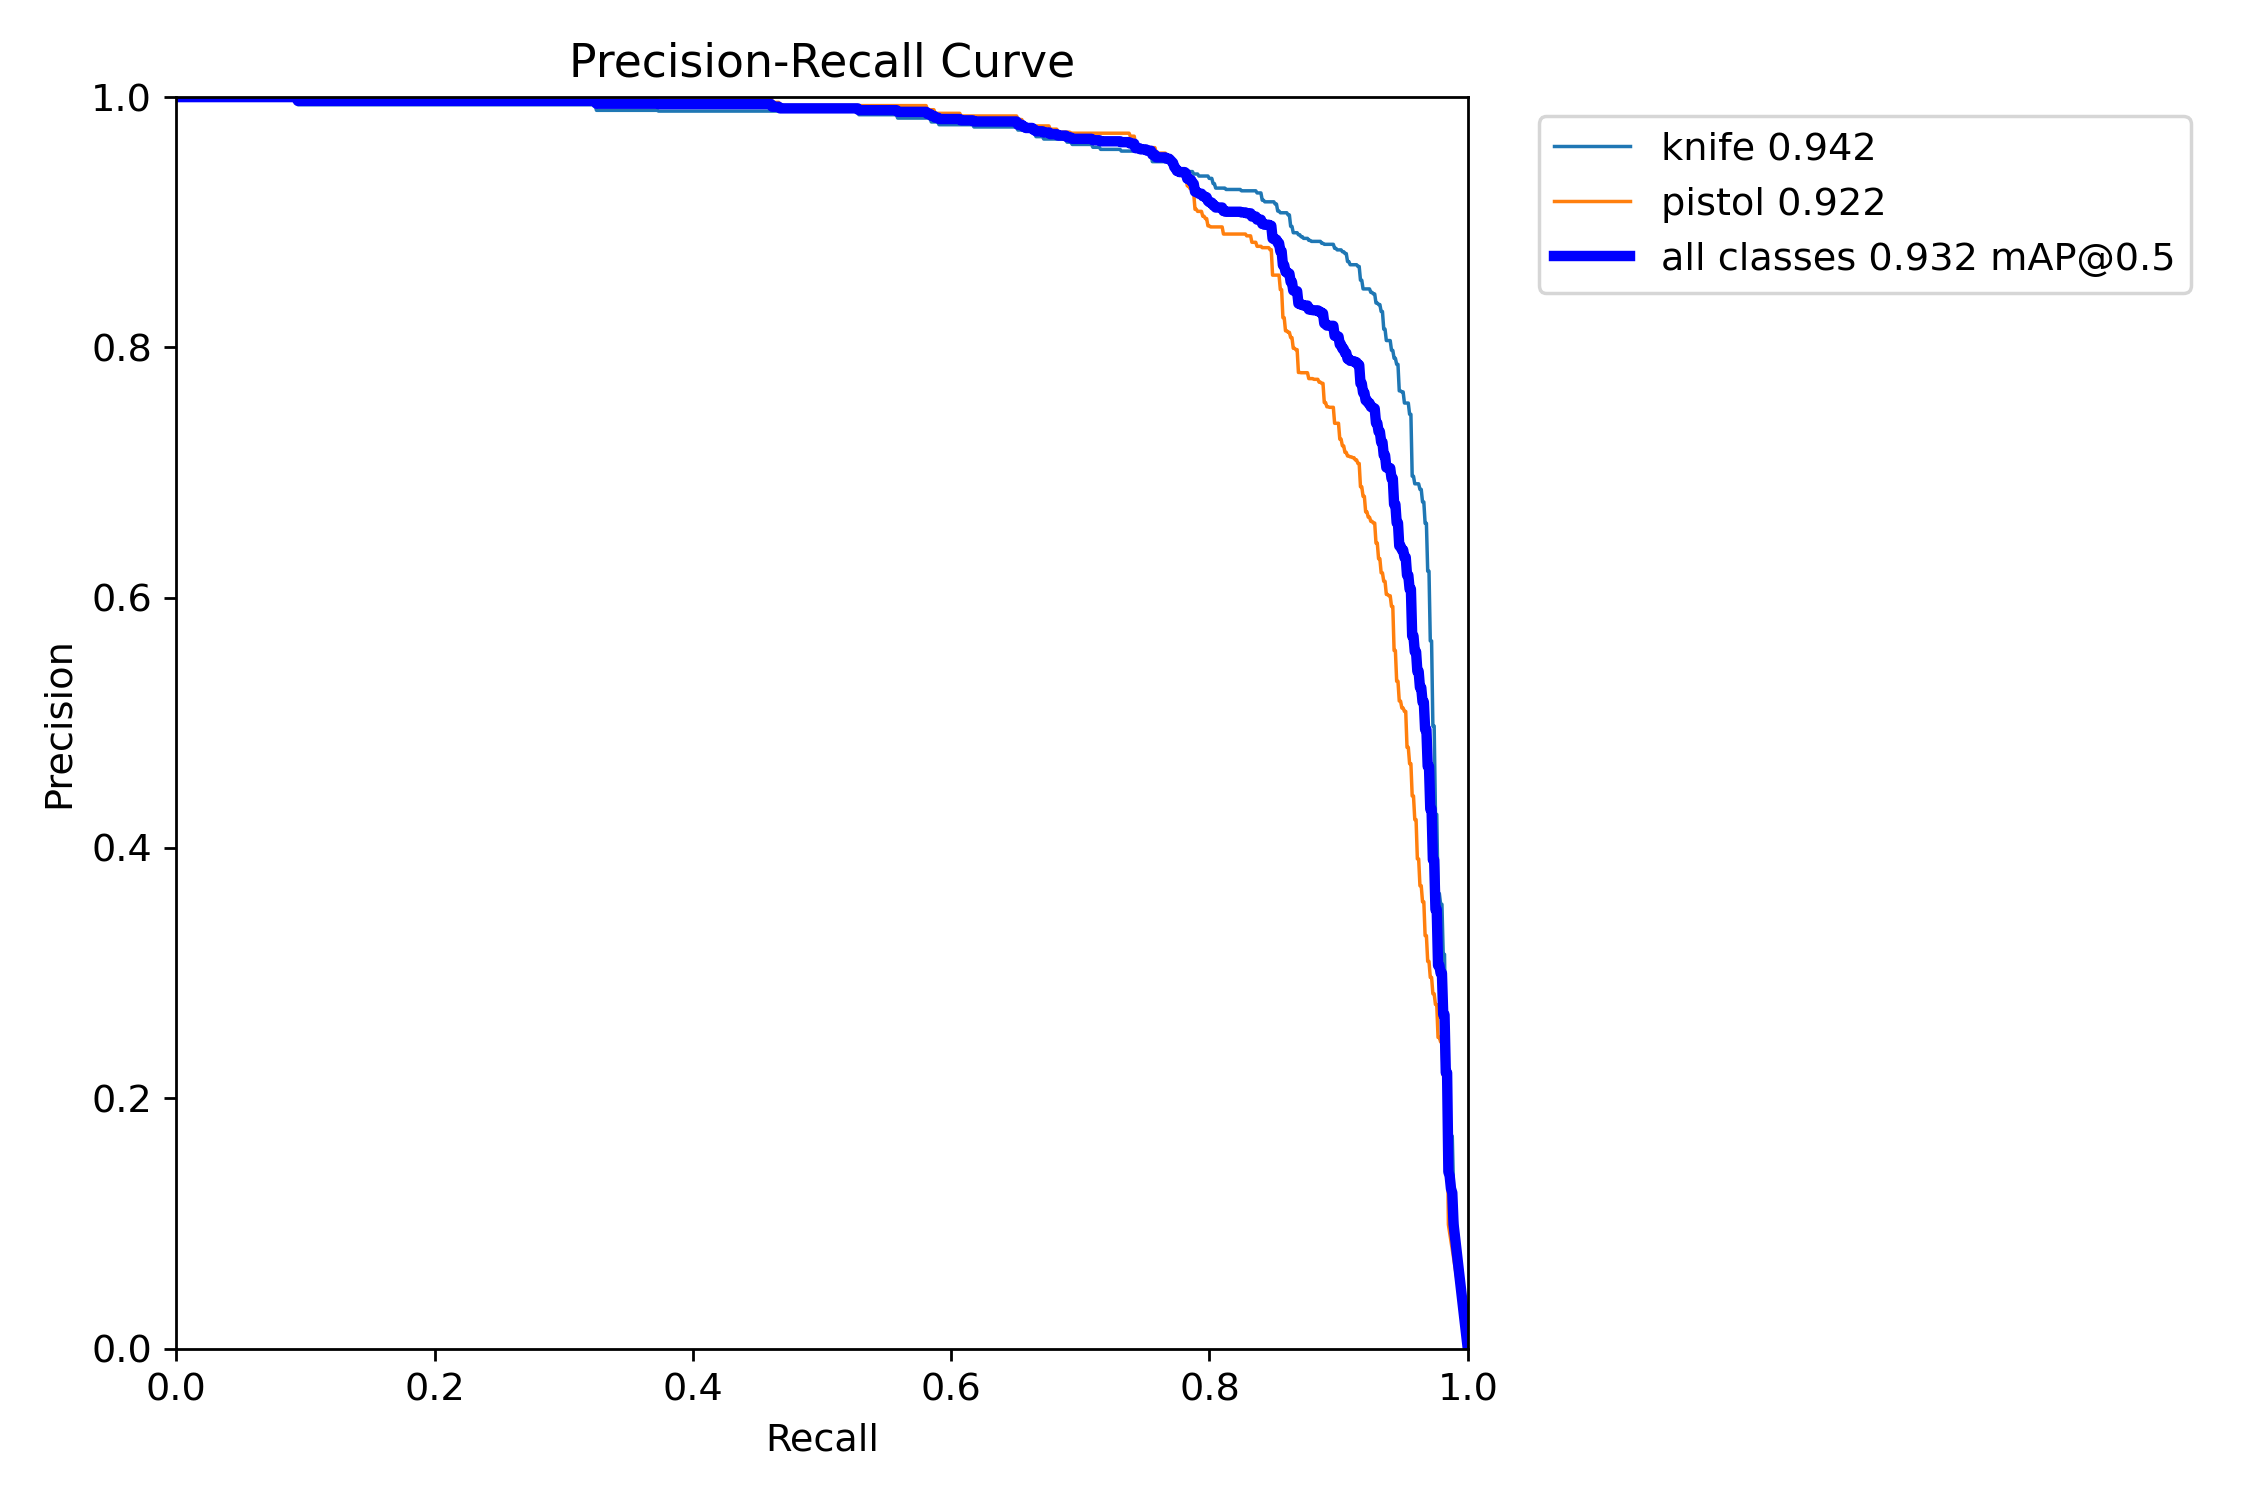

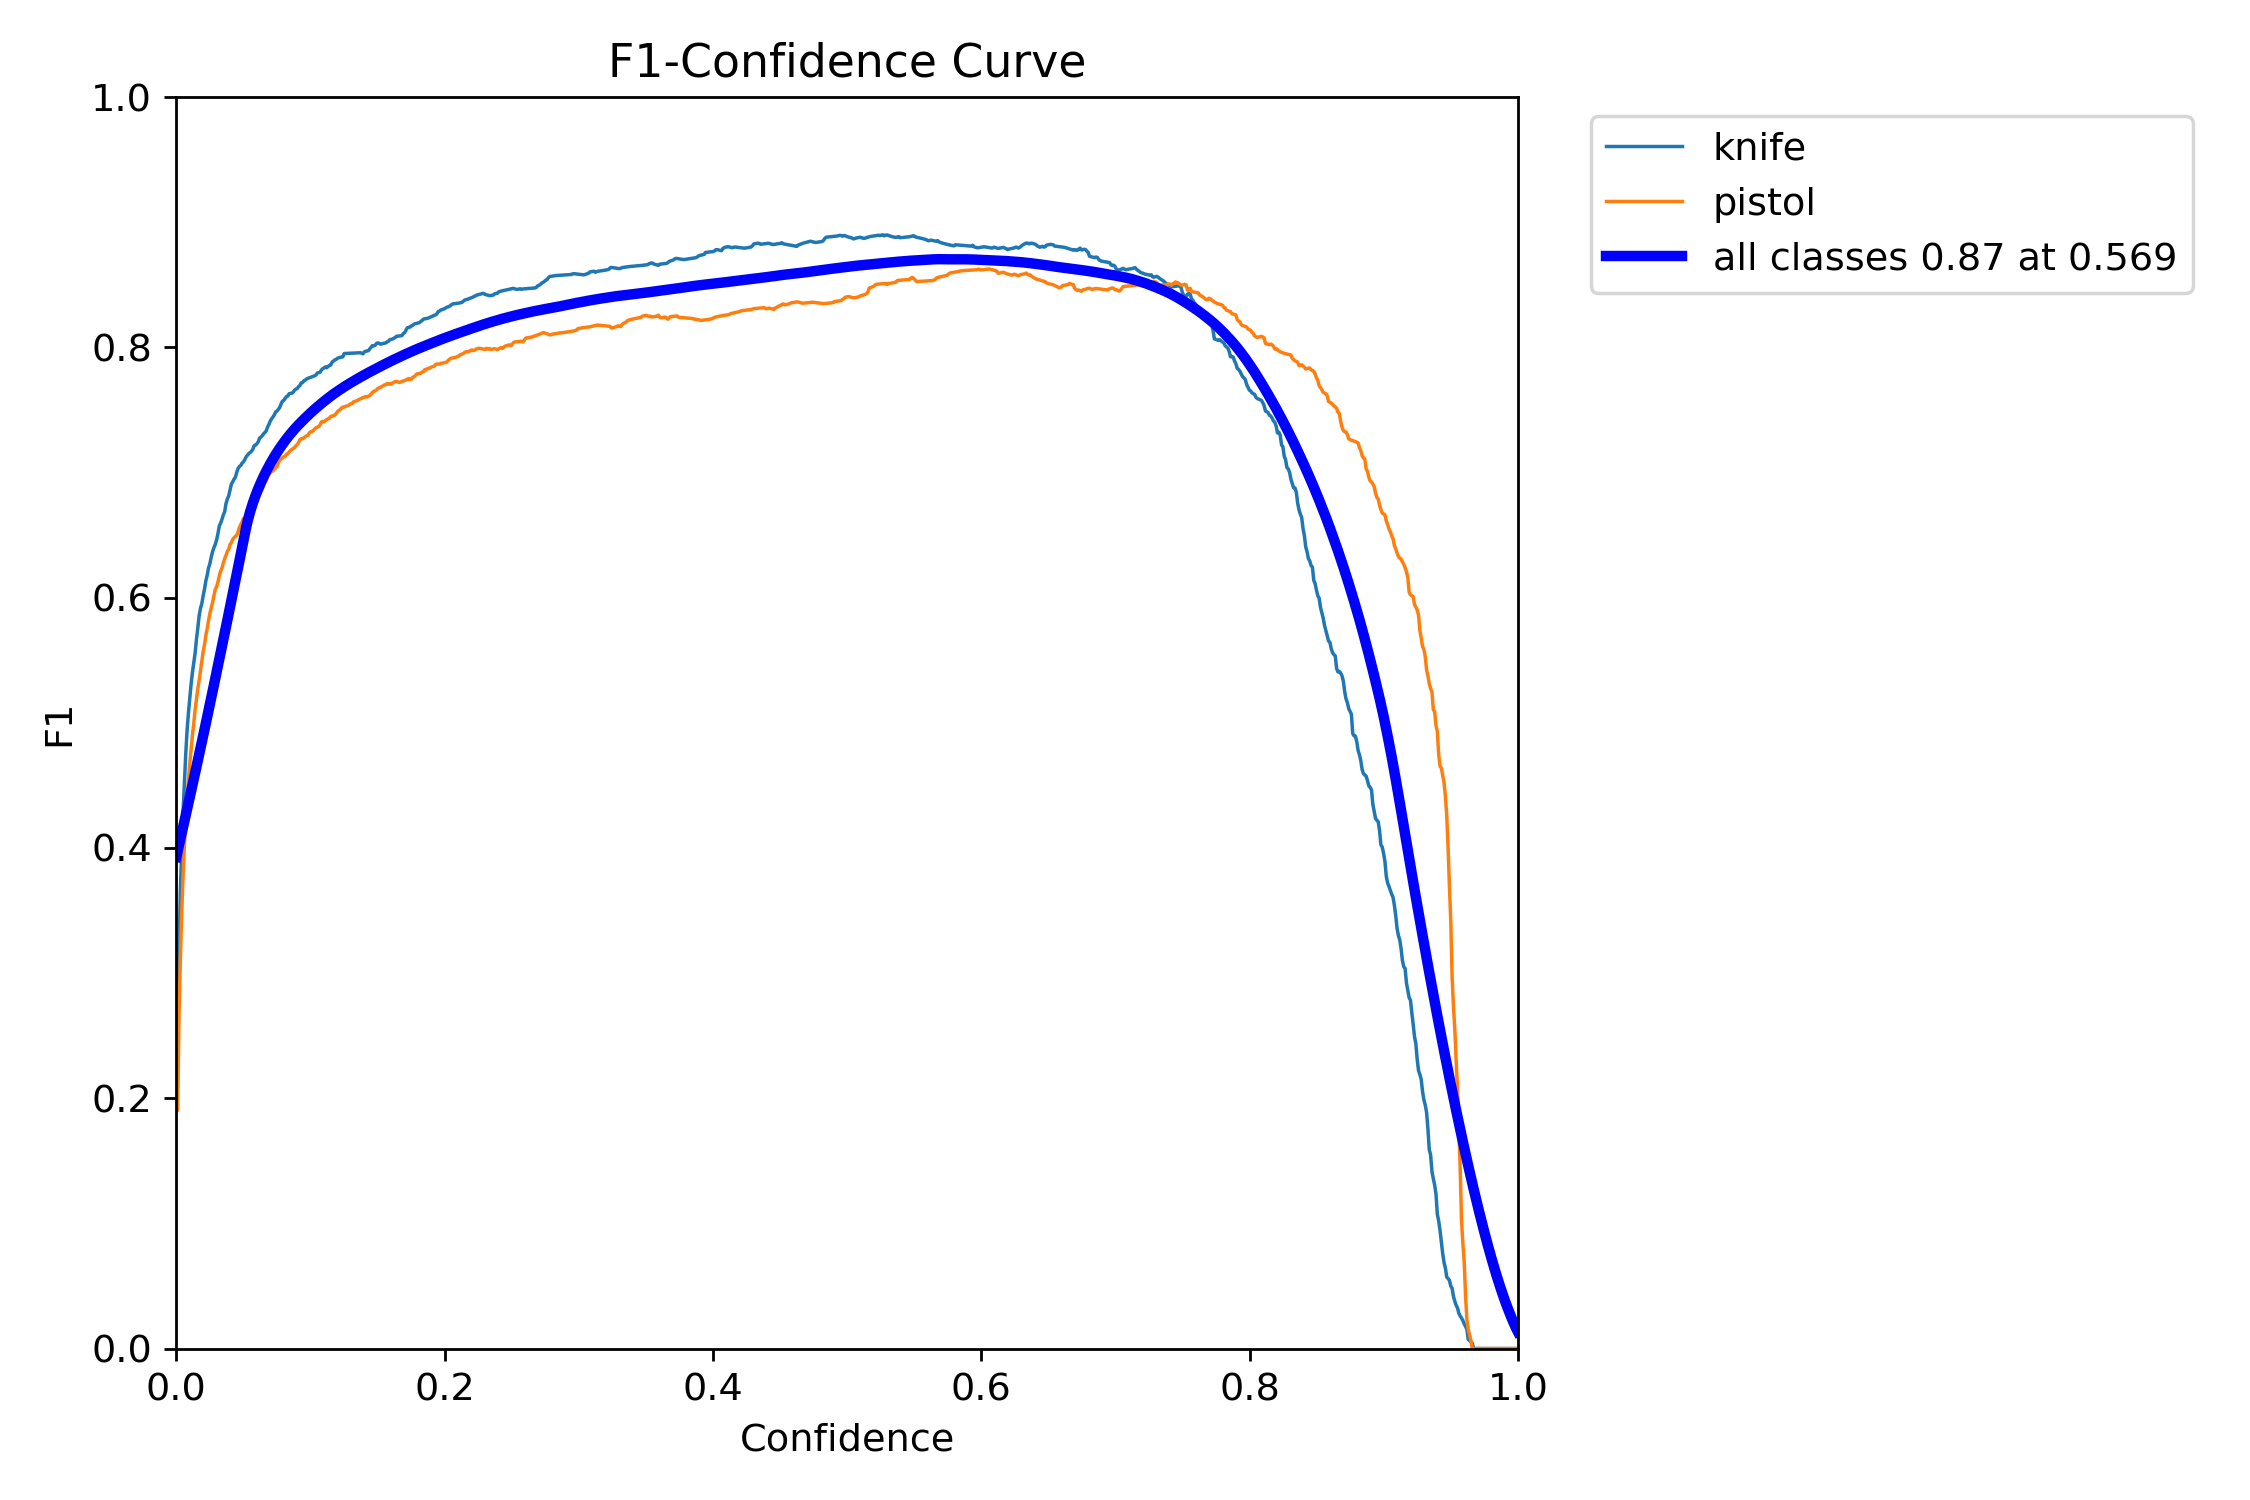

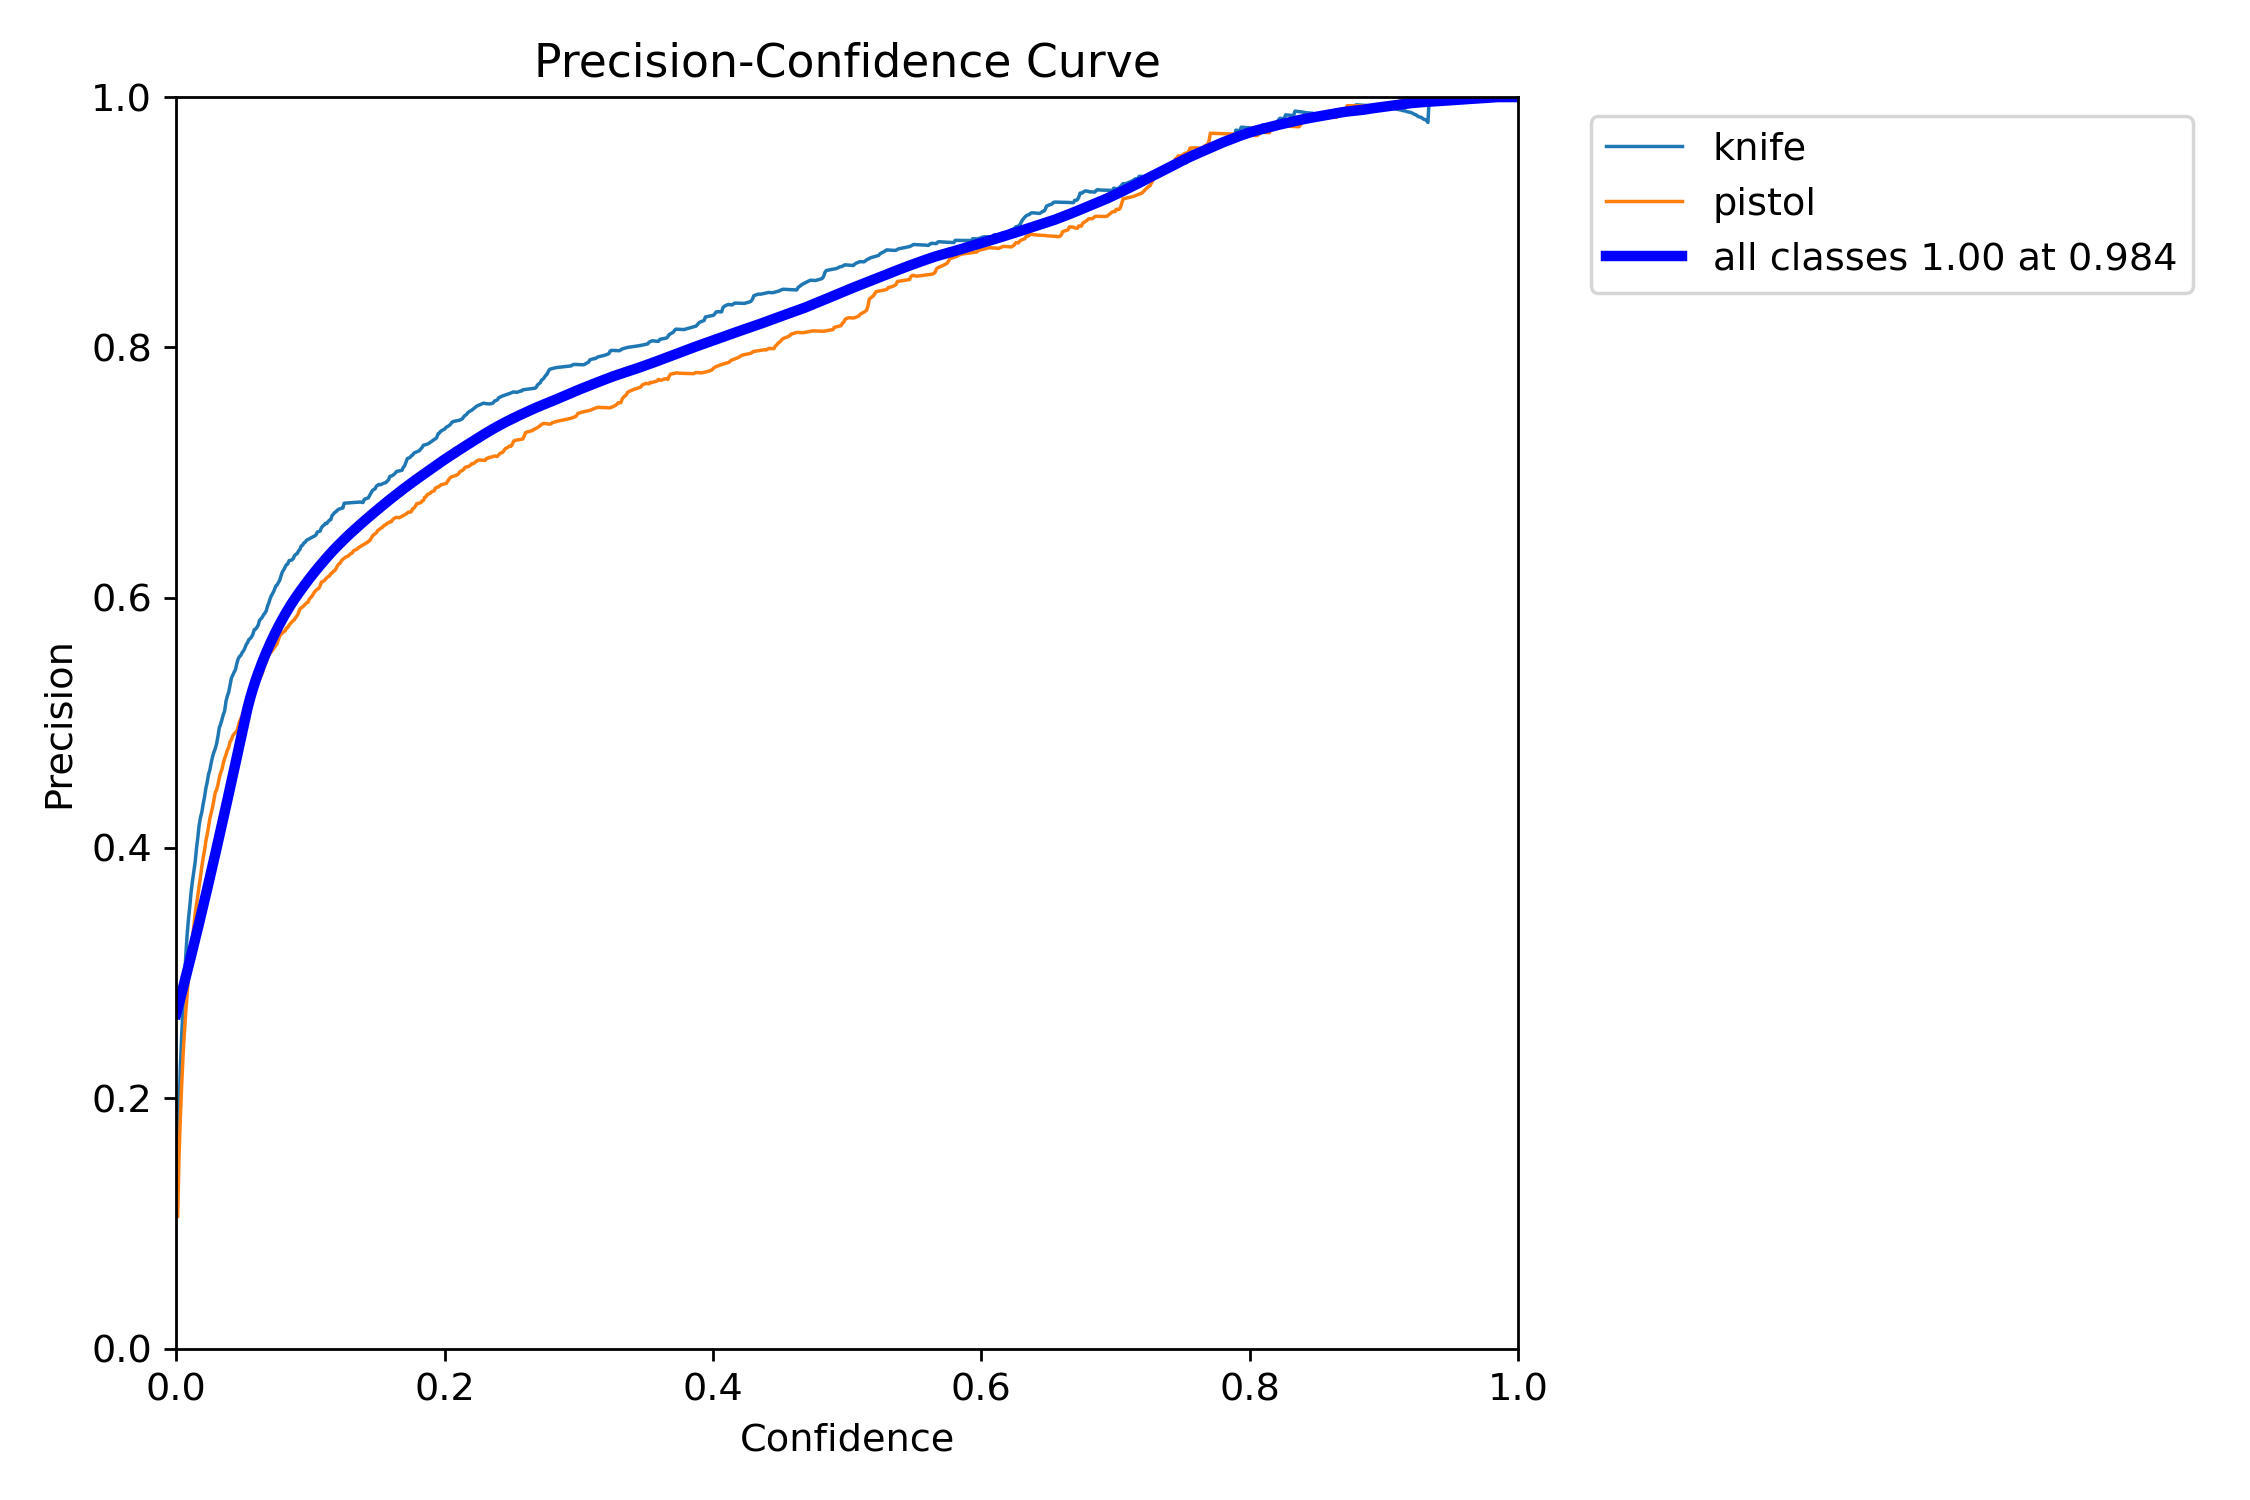

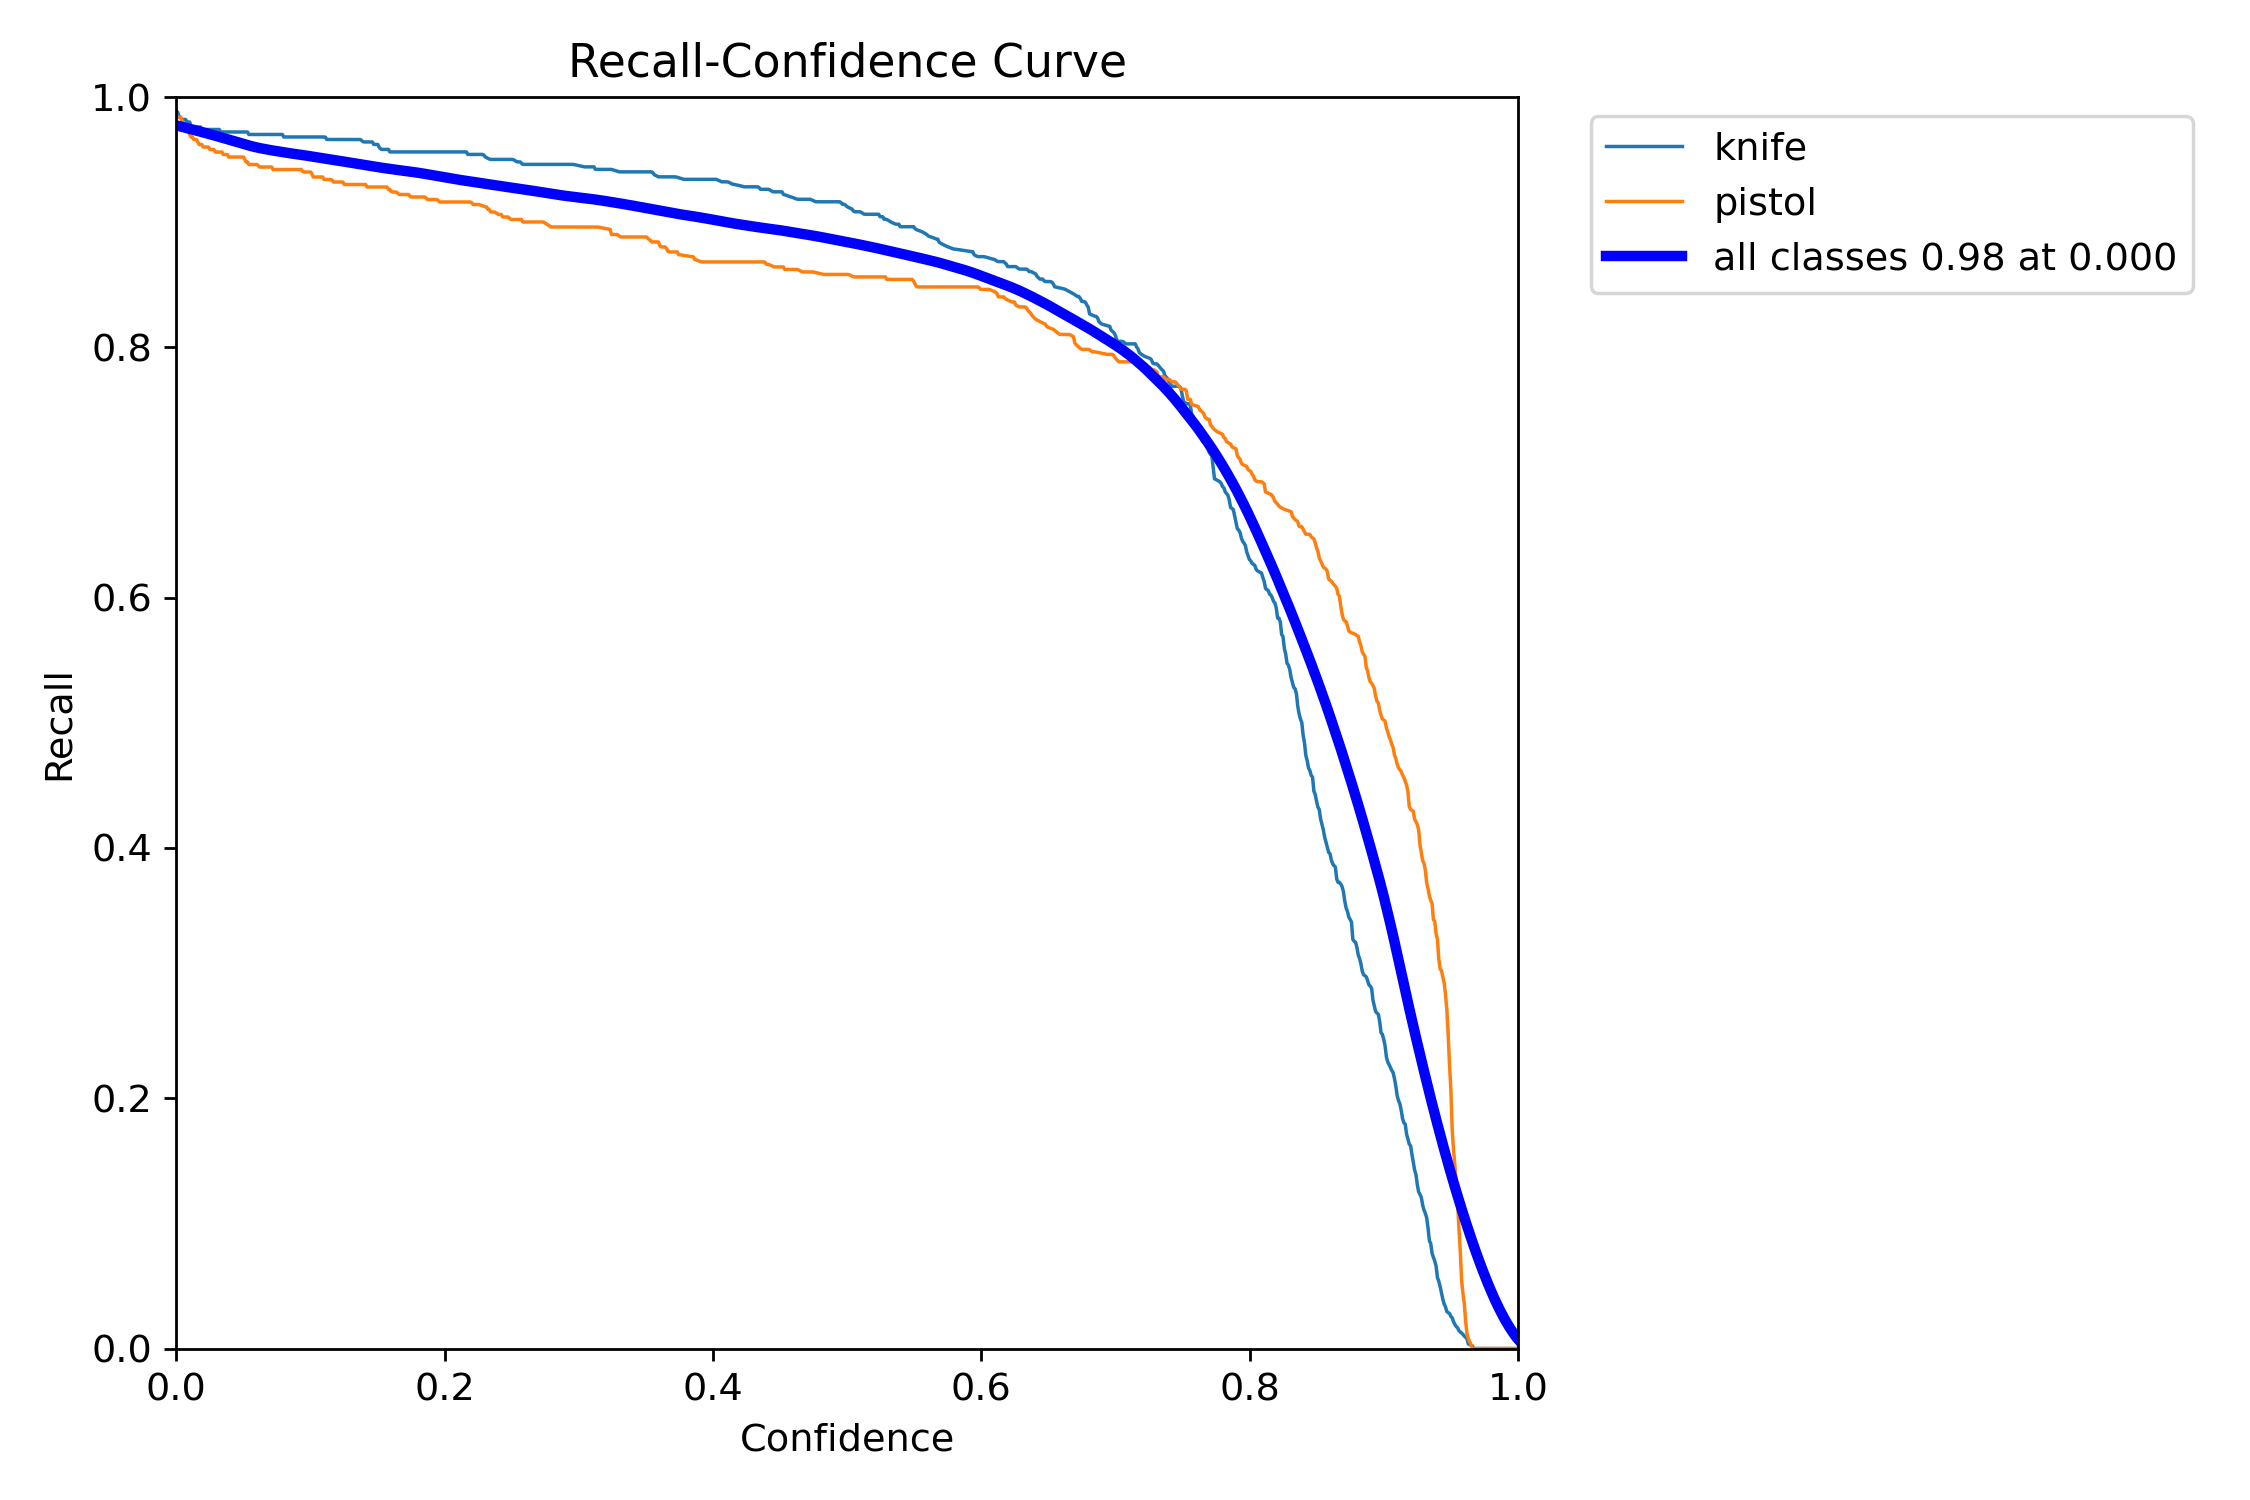

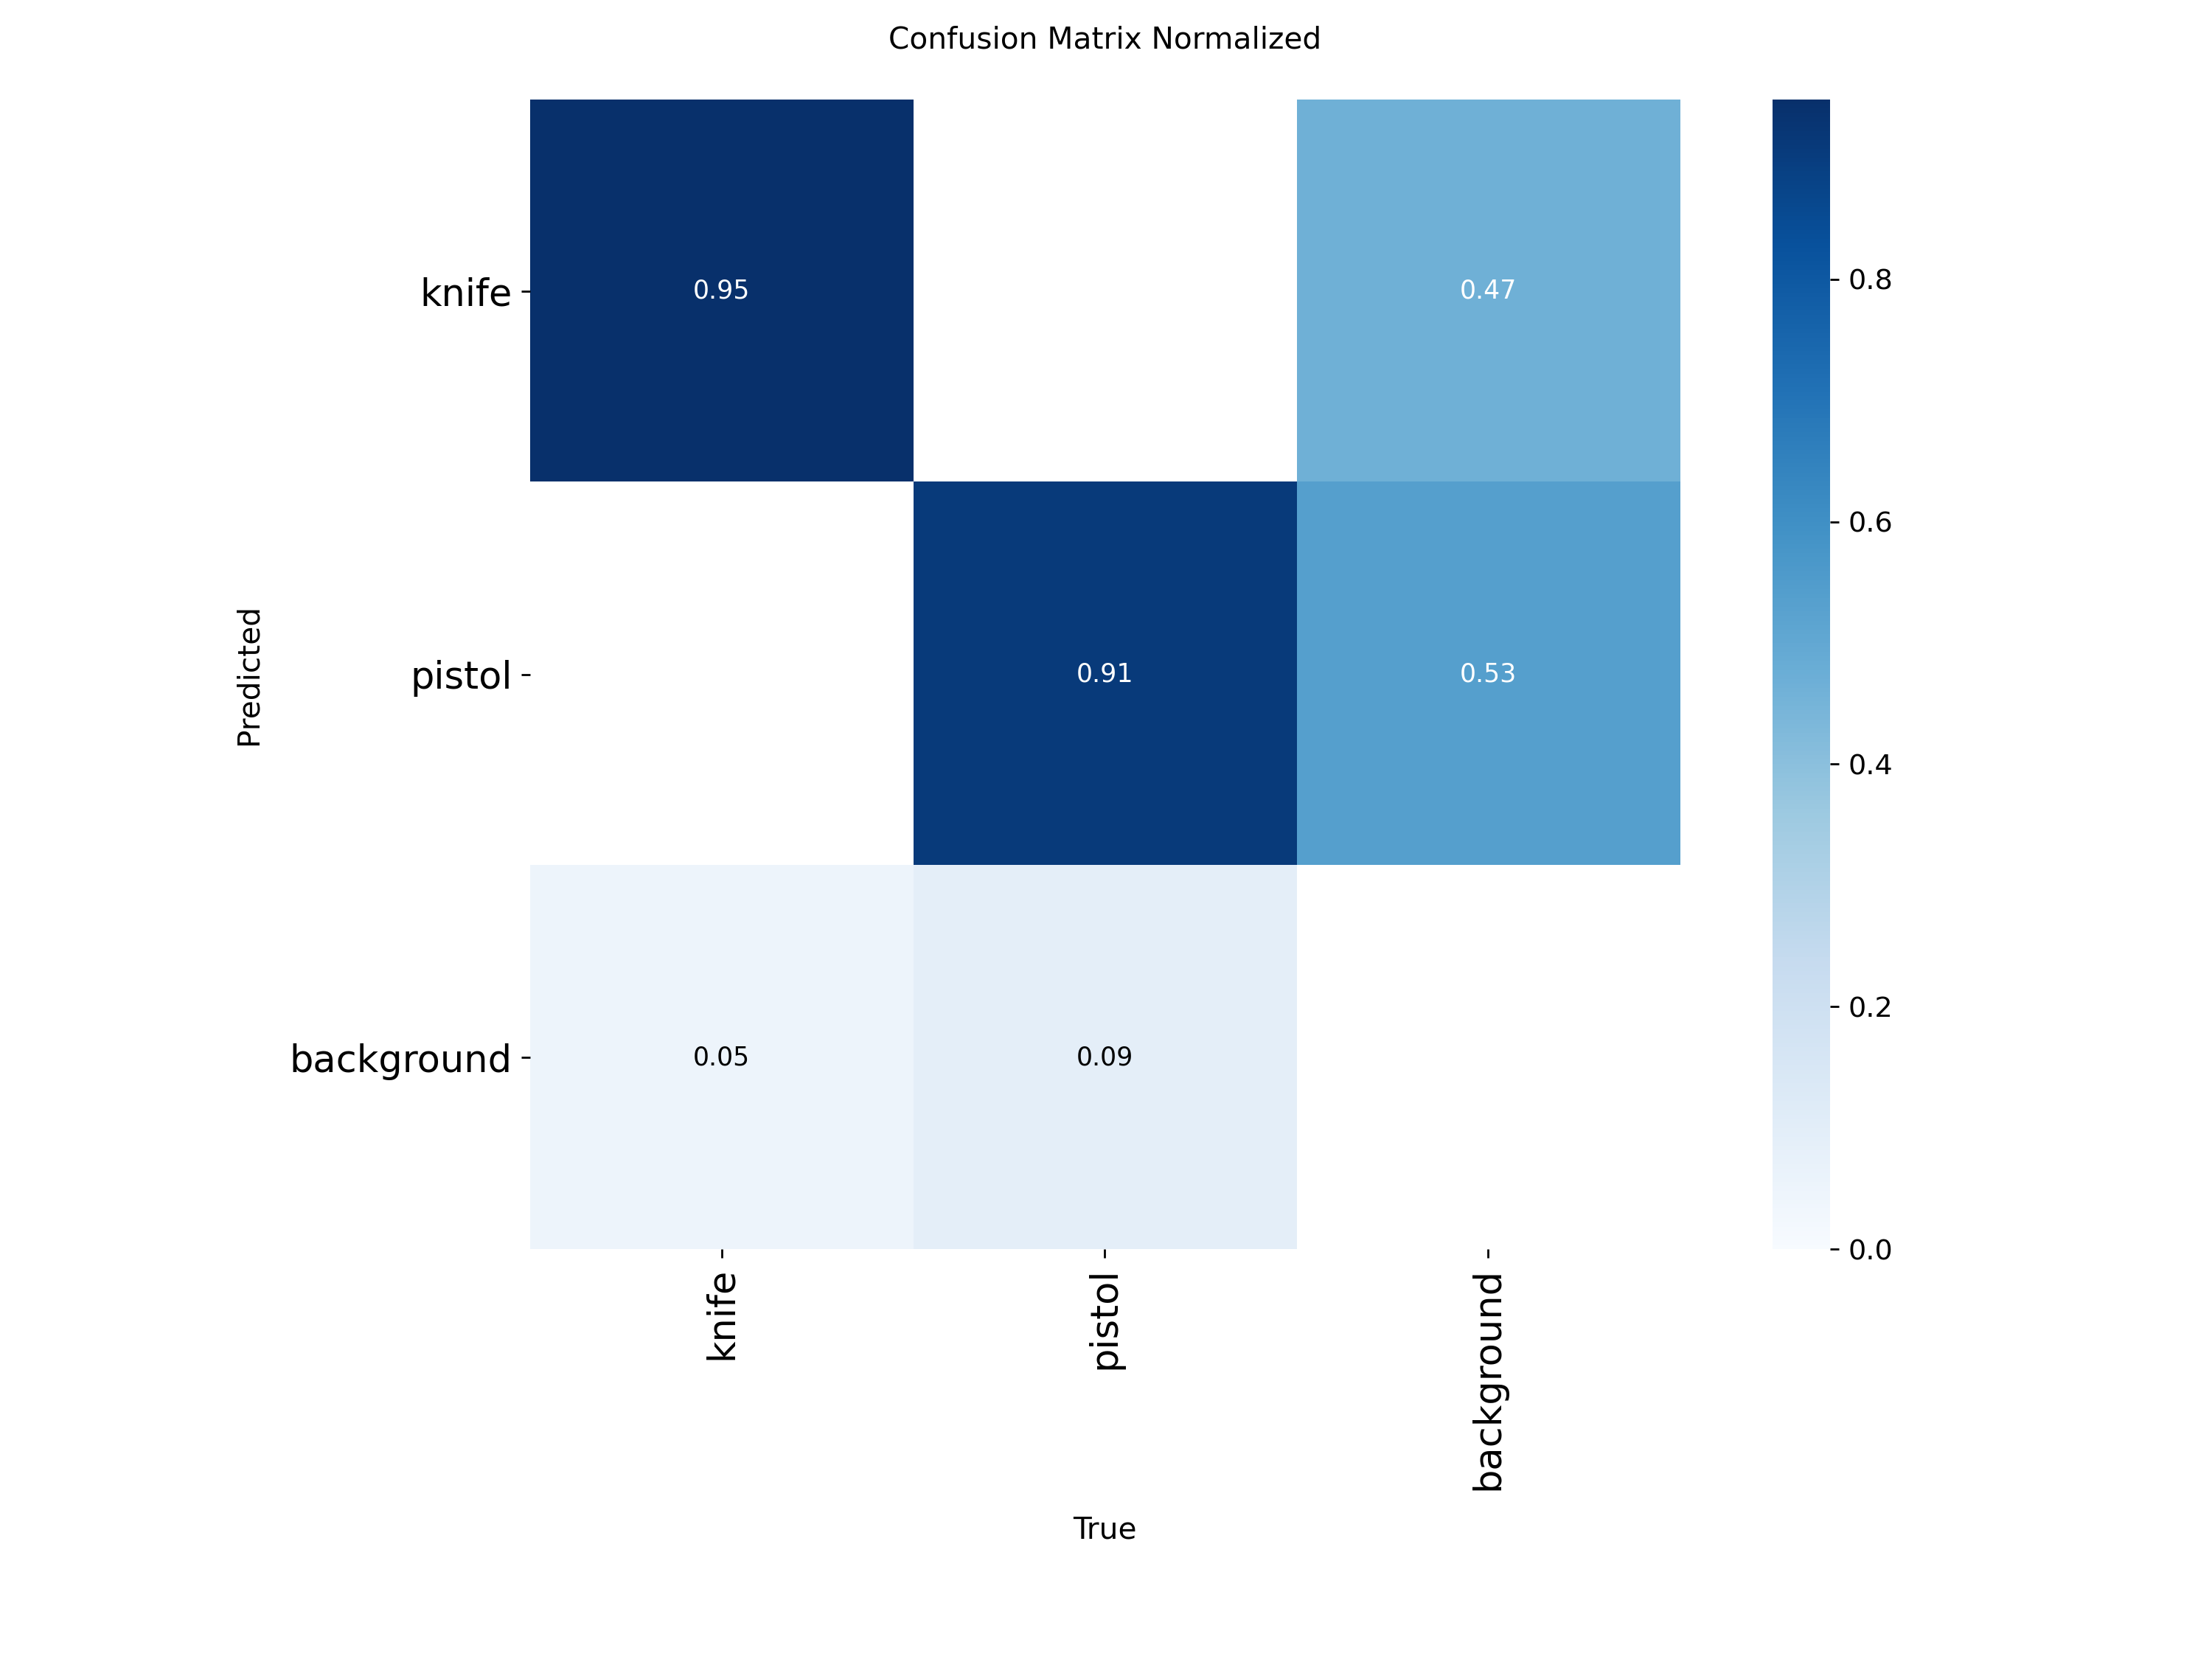

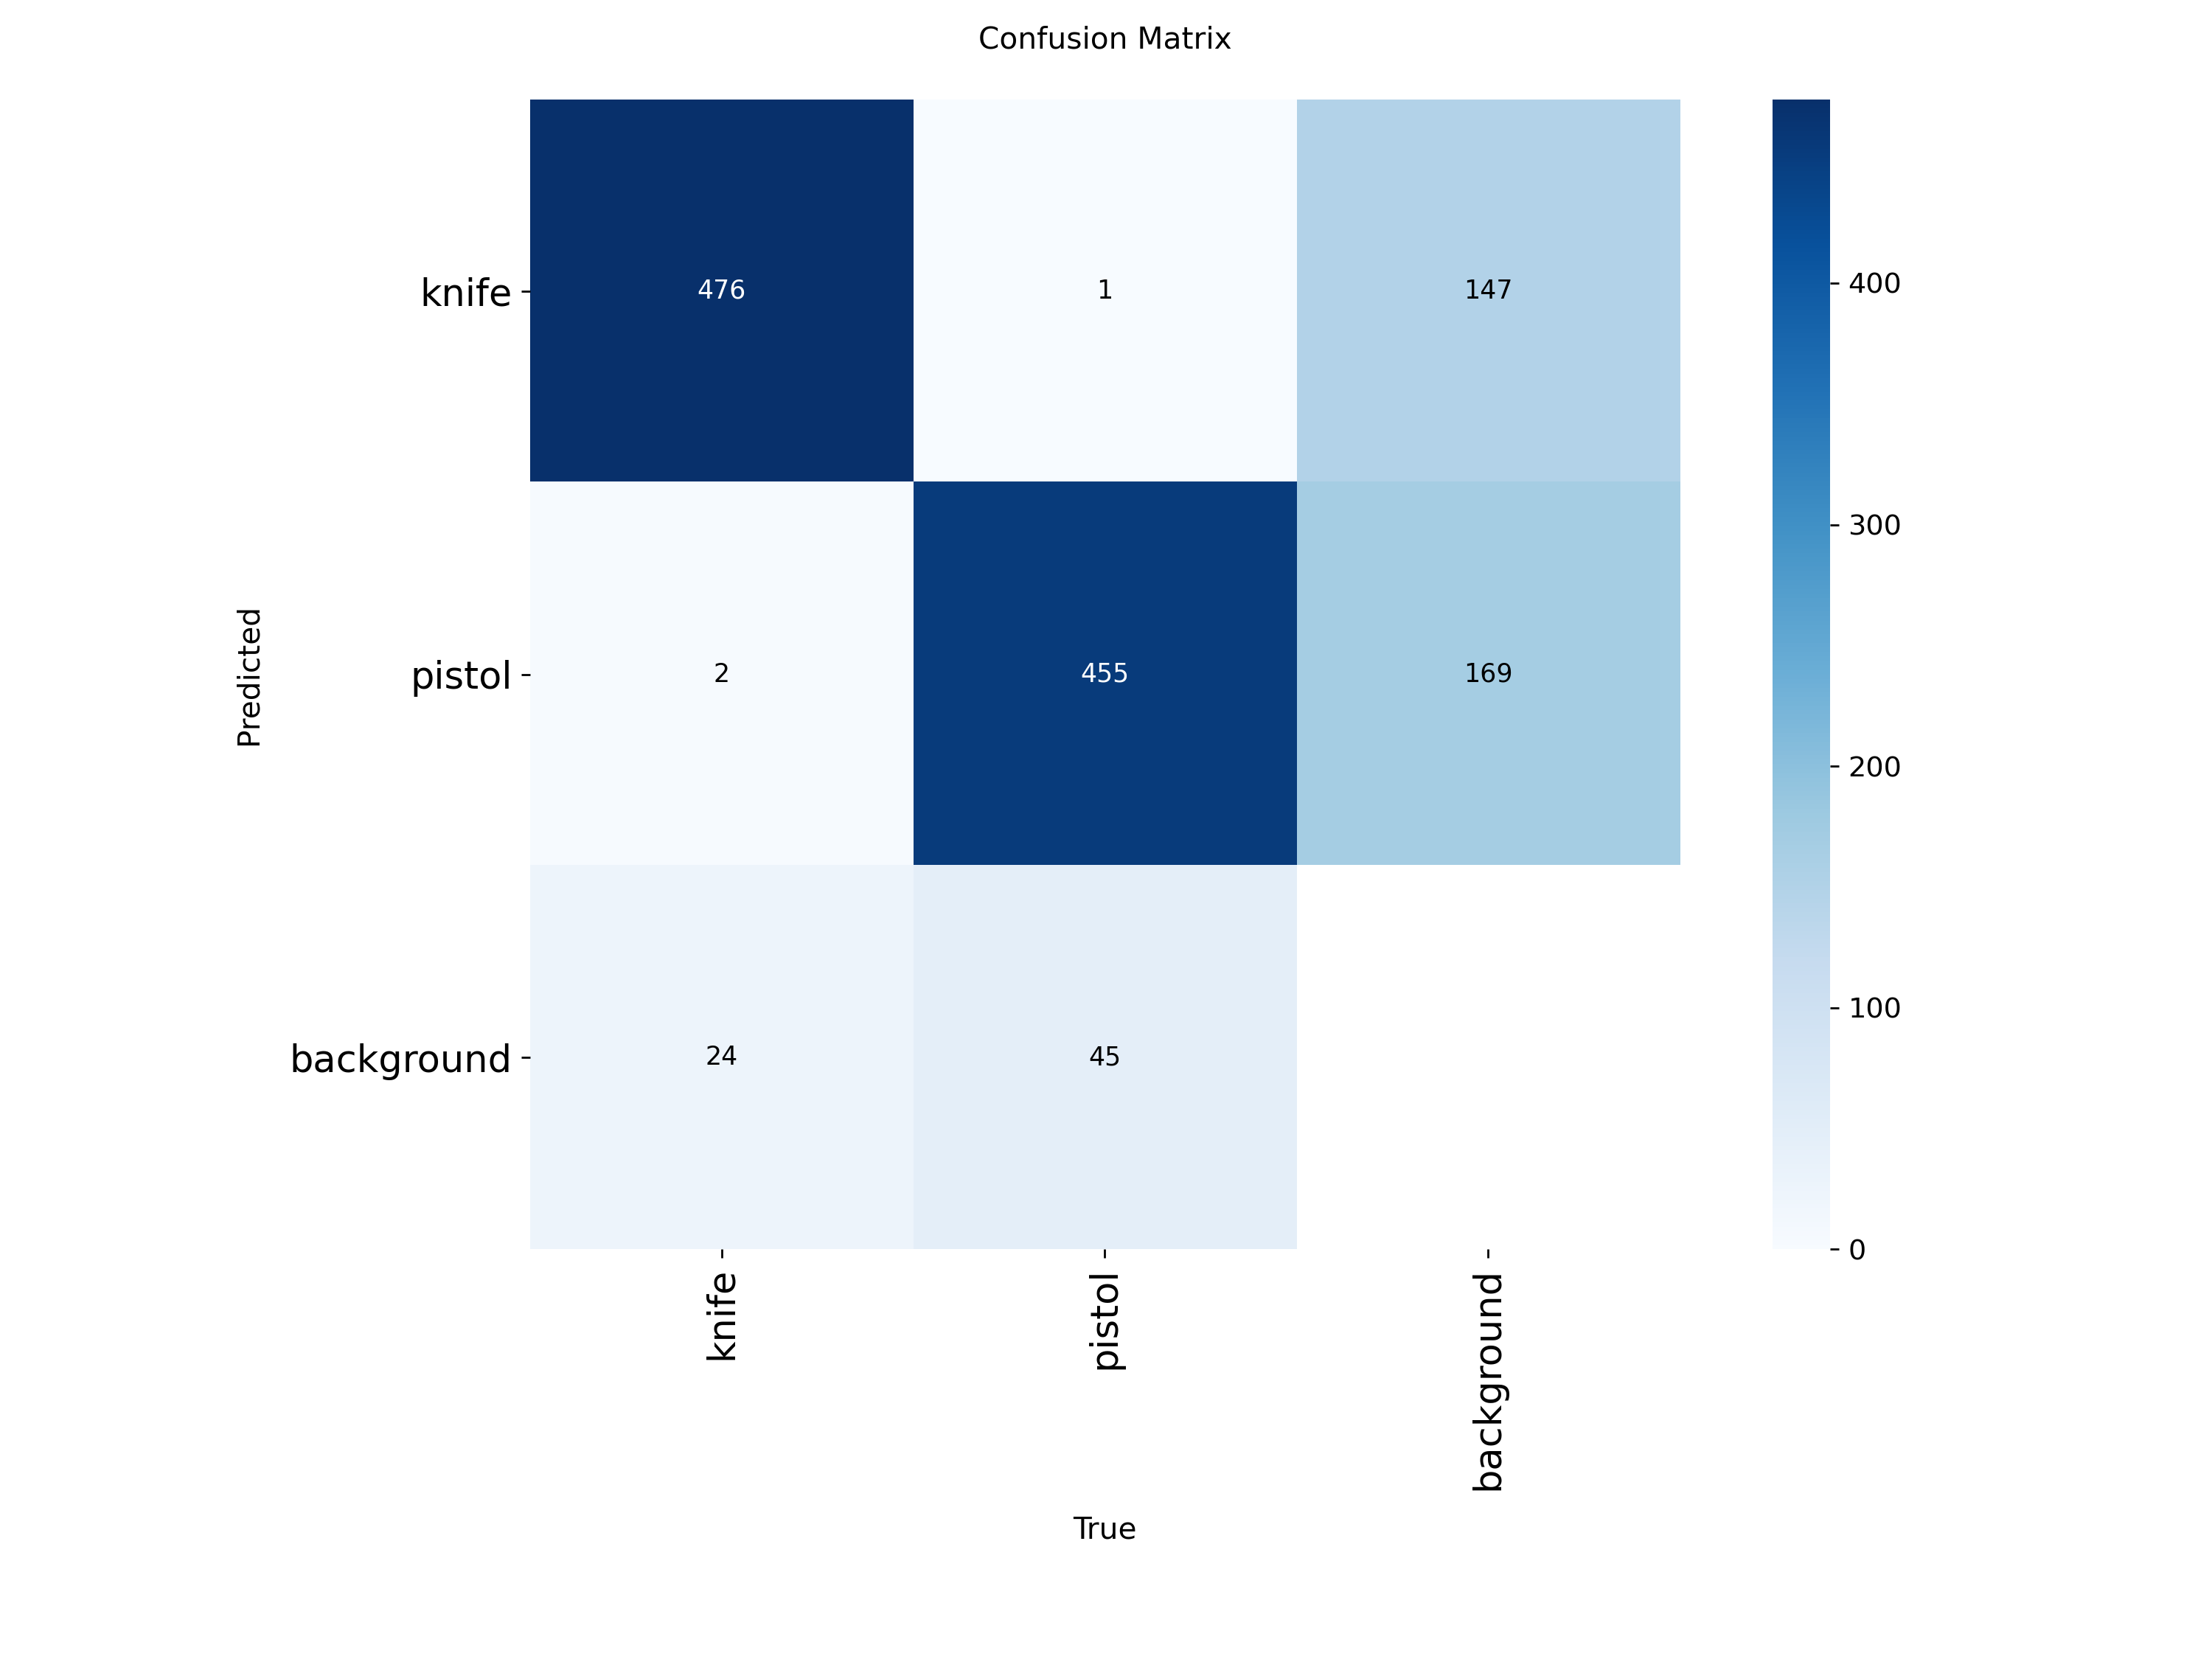

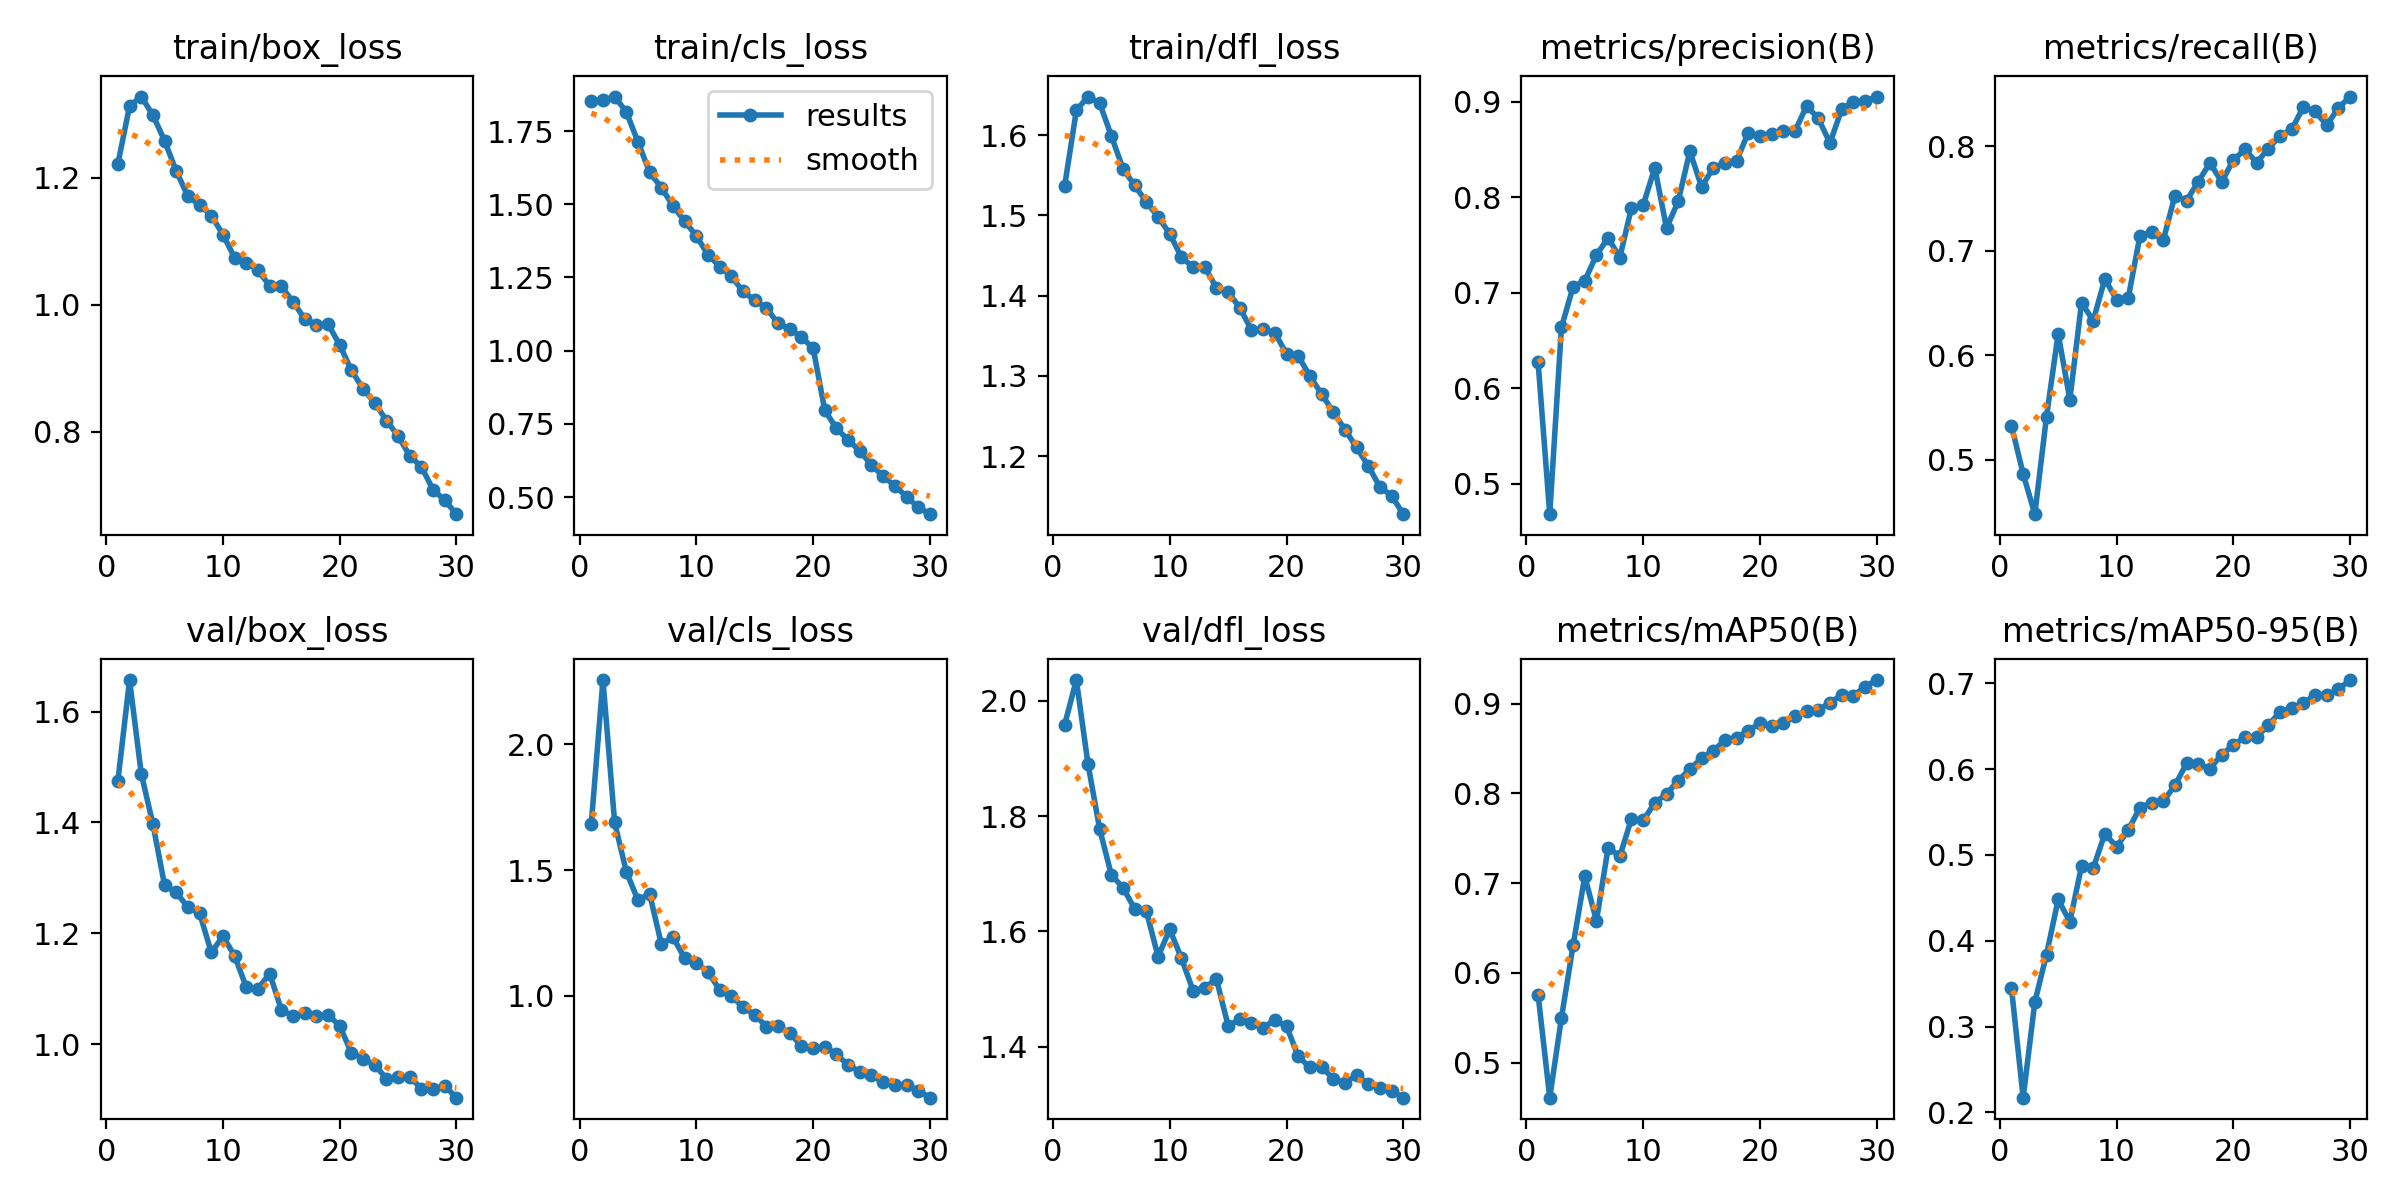

In [ ]:
from IPython.display import Image, display
for metric in glob.glob("/content/drive/MyDrive/model ml/threat detection/ThreatDetection2.3.0/runs/detect/train/*.png"):
    display(Image(filename=metric, width=800, height=500))
    print("\n")


# Inference

In [ ]:
Model = YOLO("/content/drive/MyDrive/model ml/threat detection/ThreatDetection2.3.0/runs/detect/train/weights/best.pt")
results = Model.predict(conf=0.5, source="/content/drive/MyDrive/model ml/threat detection/gun&knife-1/test/images")

# Directory to save the results
save_dir = '/content/drive/MyDrive/model ml/threat detection/ThreatDetection2.3.0/detected_images/'
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it does not exist

# Save results to the directory
for i, result in enumerate(results):
    # Generate a filename for each result
    filename = os.path.join(save_dir, f'detected_image_{i}.jpg')
    result.save(filename=filename)


image 1/441 /content/drive/MyDrive/model ml/threat detection/gun&knife-1/test/images/-_-_jpg.rf.112510e432dcf781f02a2233bd42fccc.jpg: 640x640 1 knife, 37.1ms
image 2/441 /content/drive/MyDrive/model ml/threat detection/gun&knife-1/test/images/-_-_jpg.rf.9ac58d96cc434e1d333f7e20aa70fdfa.jpg: 640x640 1 knife, 37.1ms
image 3/441 /content/drive/MyDrive/model ml/threat detection/gun&knife-1/test/images/-_-_jpg.rf.c2f051c53518d8f42ba3622a12d07502.jpg: 640x640 5 knifes, 37.0ms
image 4/441 /content/drive/MyDrive/model ml/threat detection/gun&knife-1/test/images/ABbframe00349_jpg.rf.1ada30af100b1e487d3cc8ae75992879.jpg: 640x640 1 knife, 37.0ms
image 5/441 /content/drive/MyDrive/model ml/threat detection/gun&knife-1/test/images/ABbframe00370_jpg.rf.0ada57abe8de8e4406225fc7c4d5c497.jpg: 640x640 1 knife, 37.1ms
image 6/441 /content/drive/MyDrive/model ml/threat detection/gun&knife-1/test/images/ABmframe00163_jpg.rf.58ce4f959e388dc524382fc8ddd6d435.jpg: 640x640 1 knife, 37.0ms
image 7/441 /content

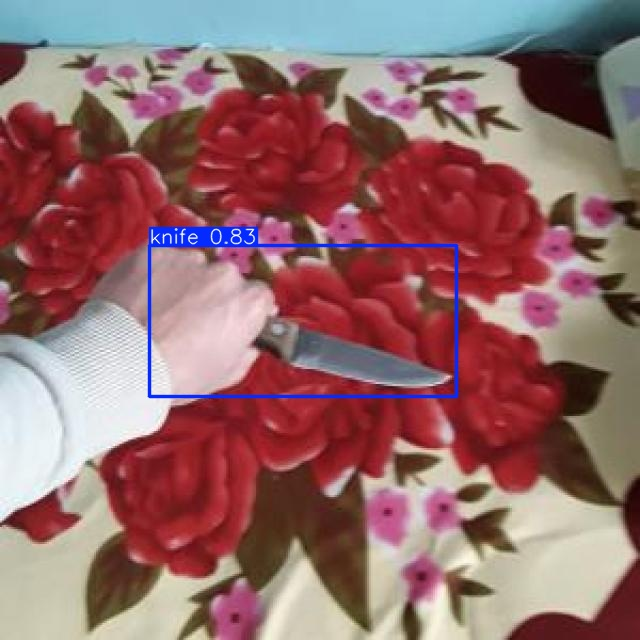

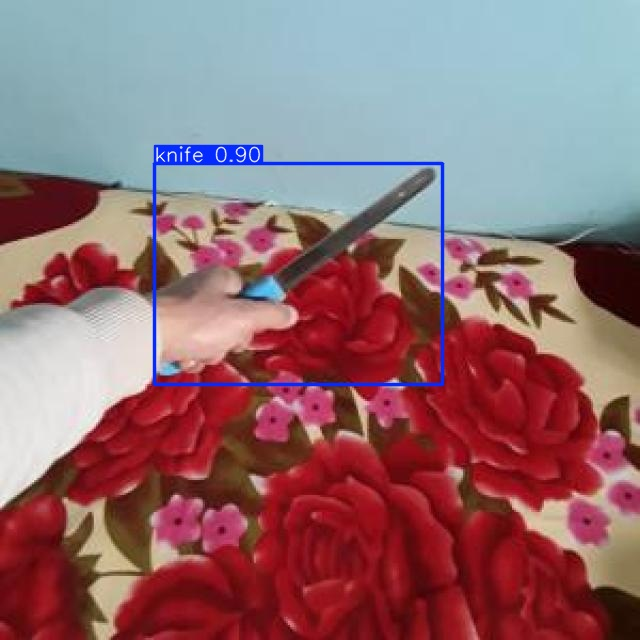

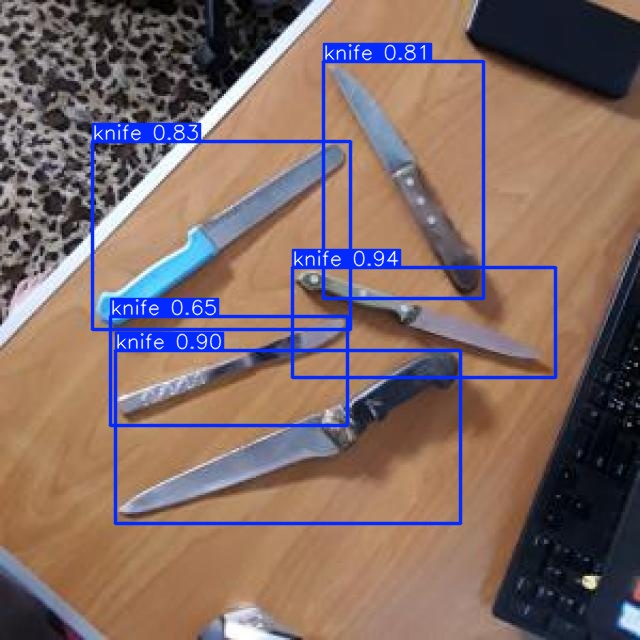

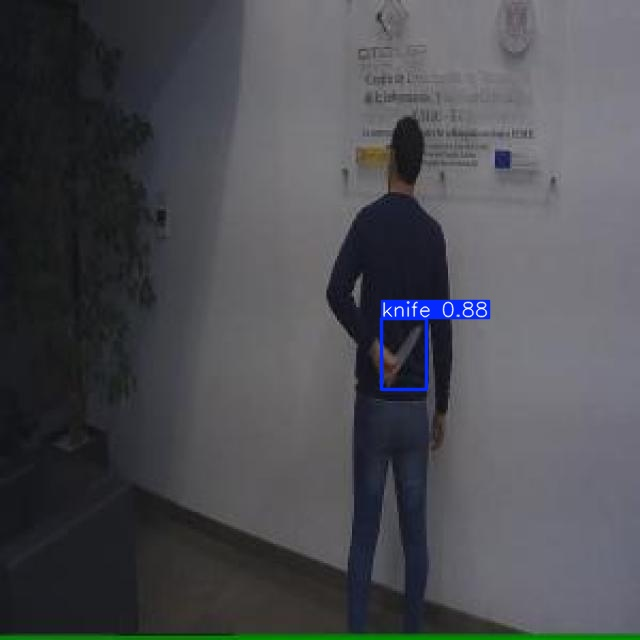

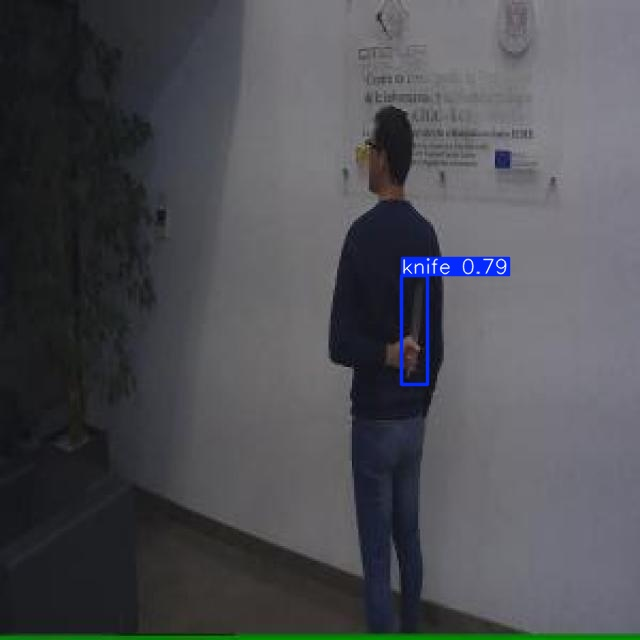

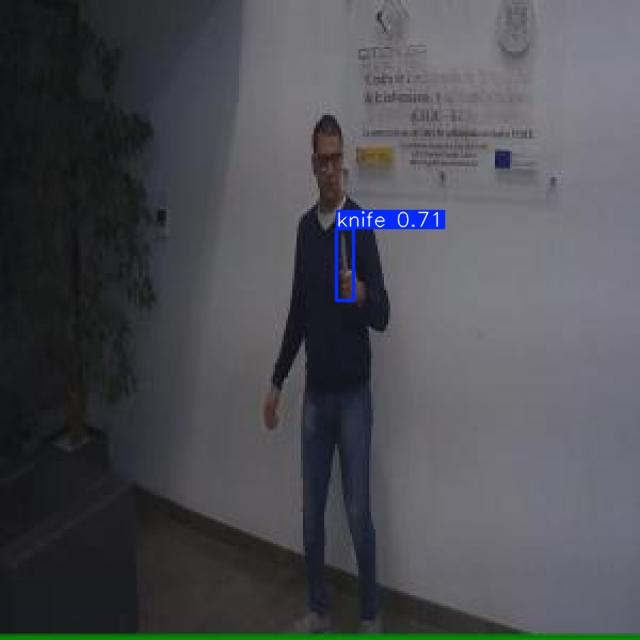

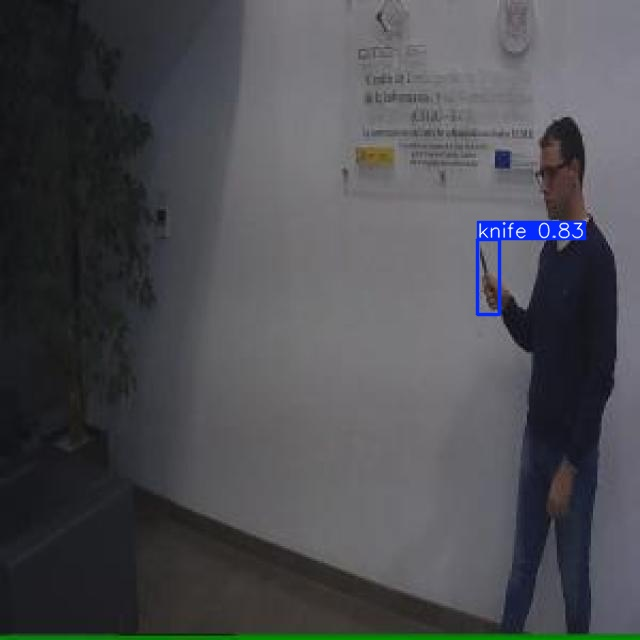

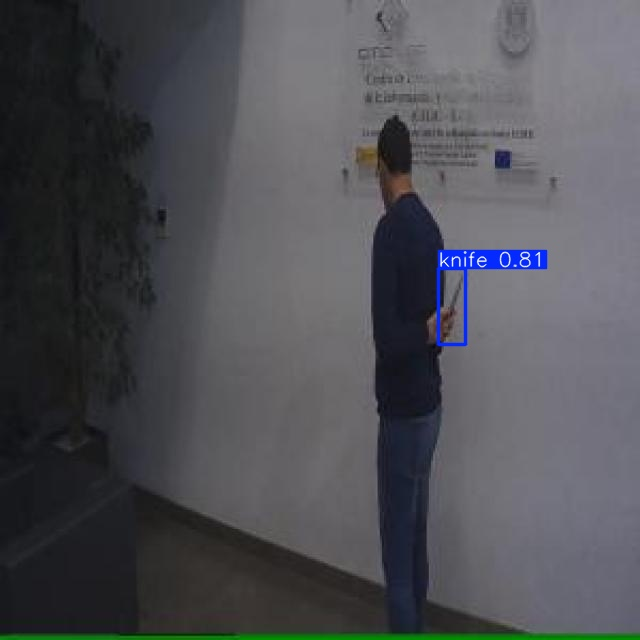

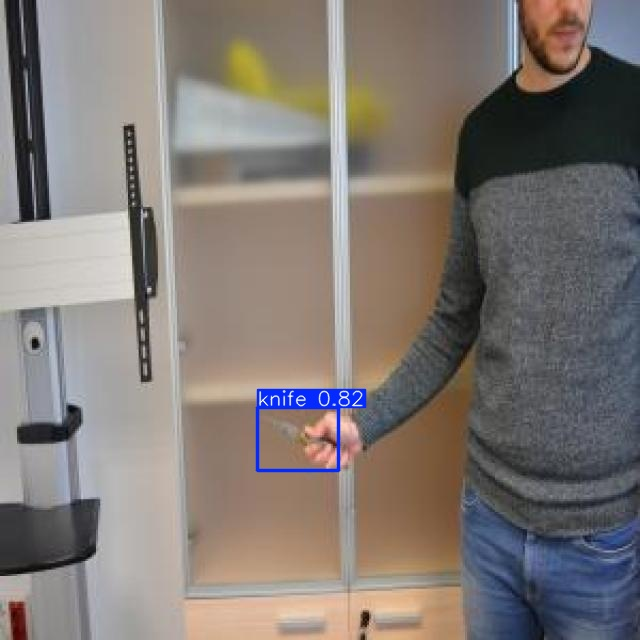

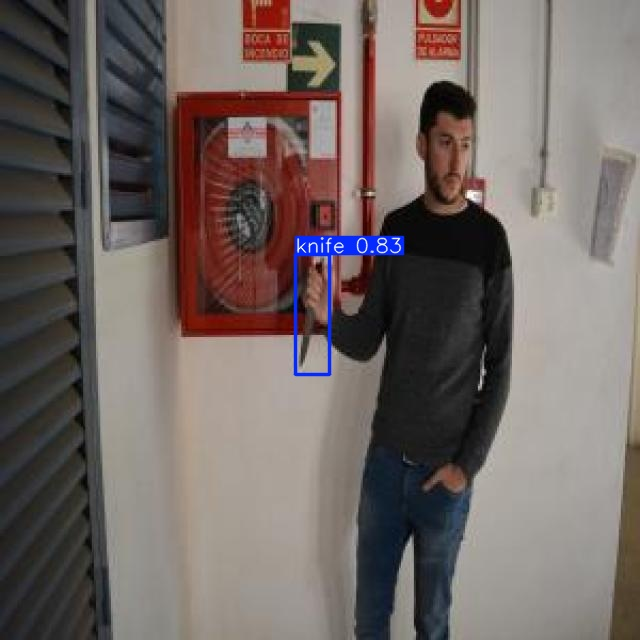

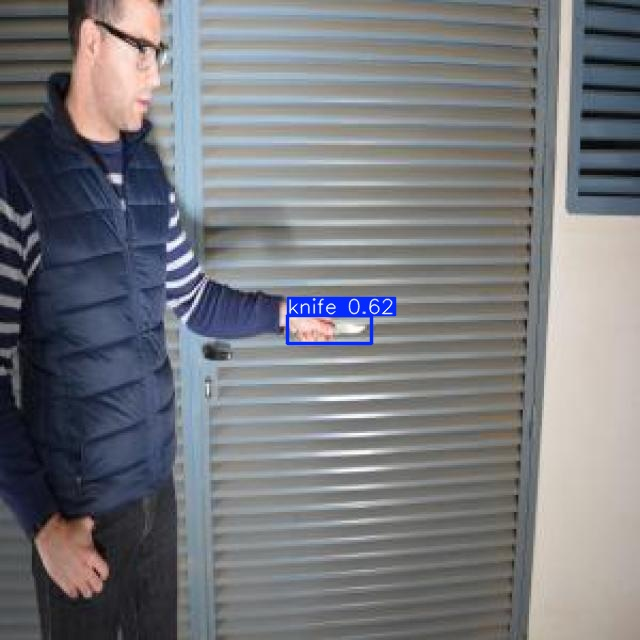

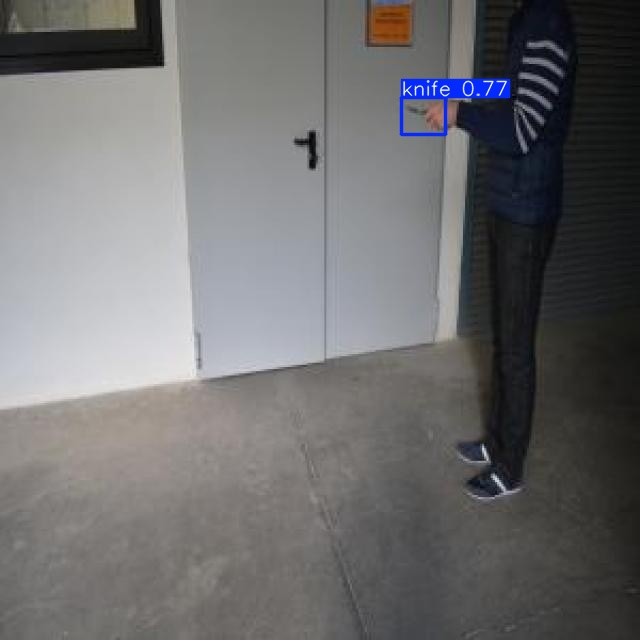

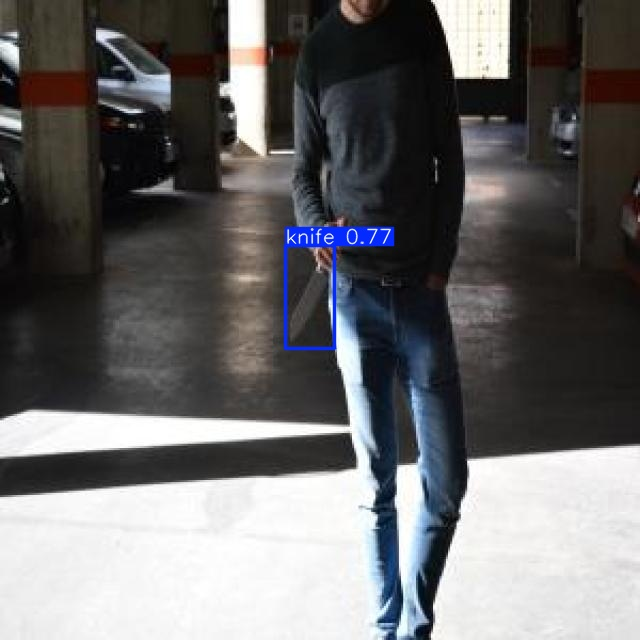

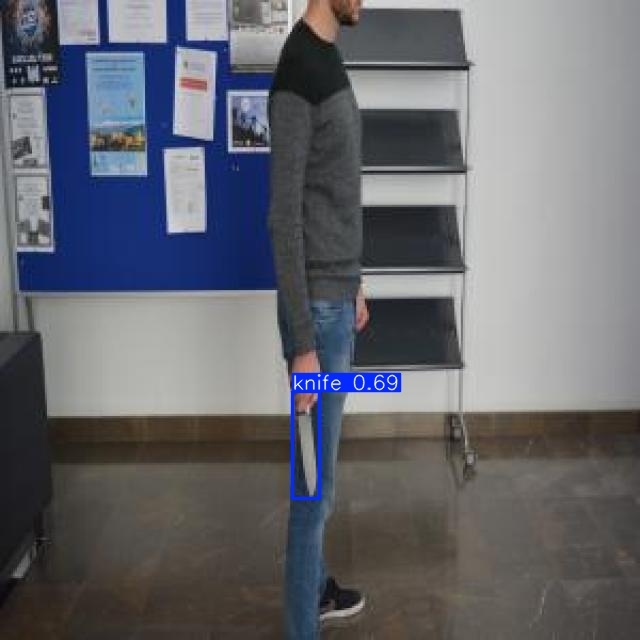

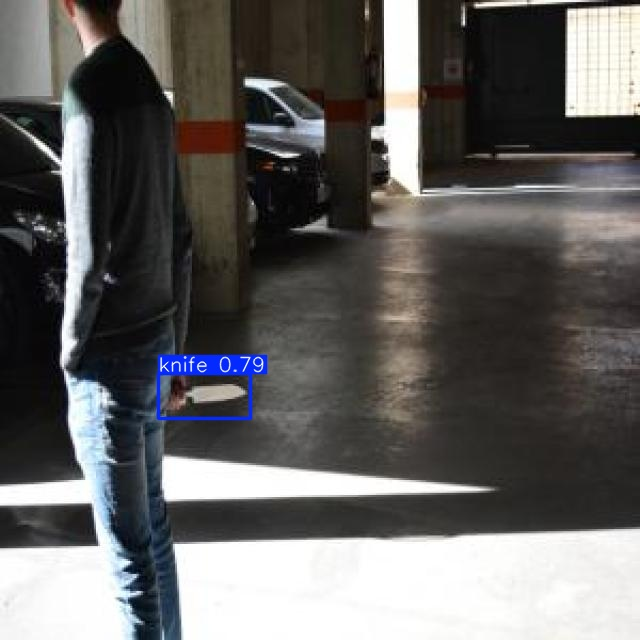

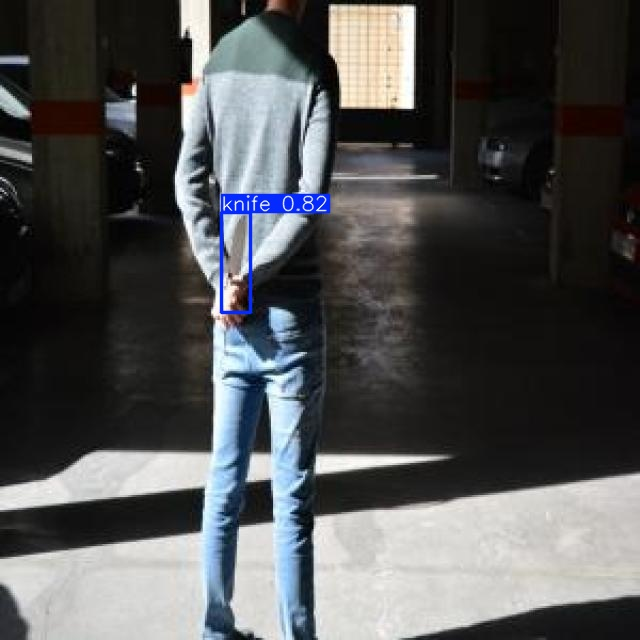

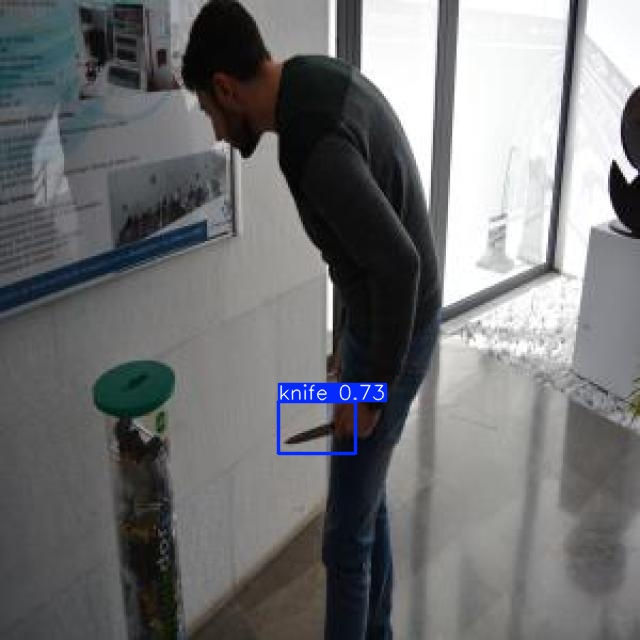

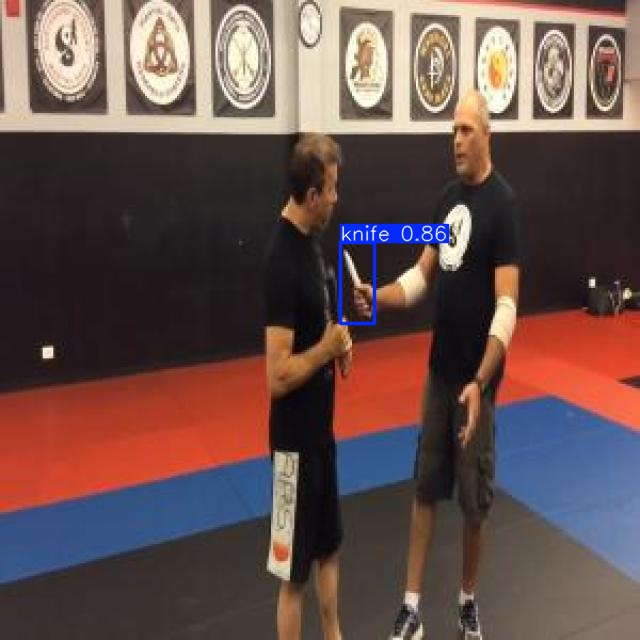

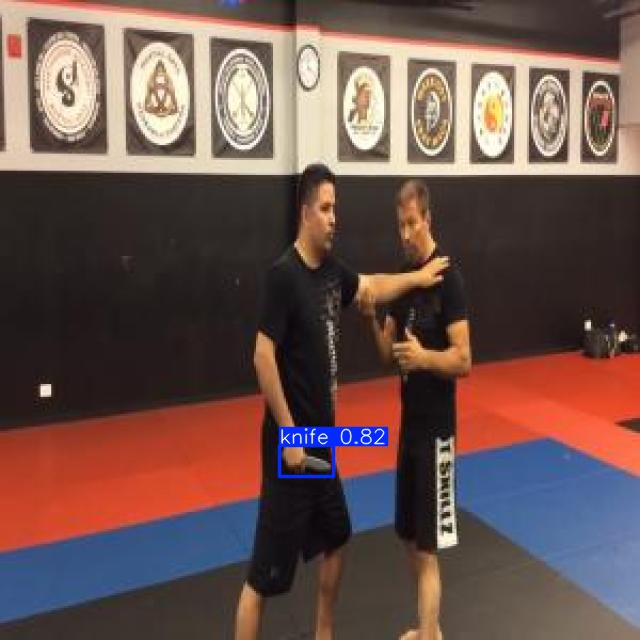

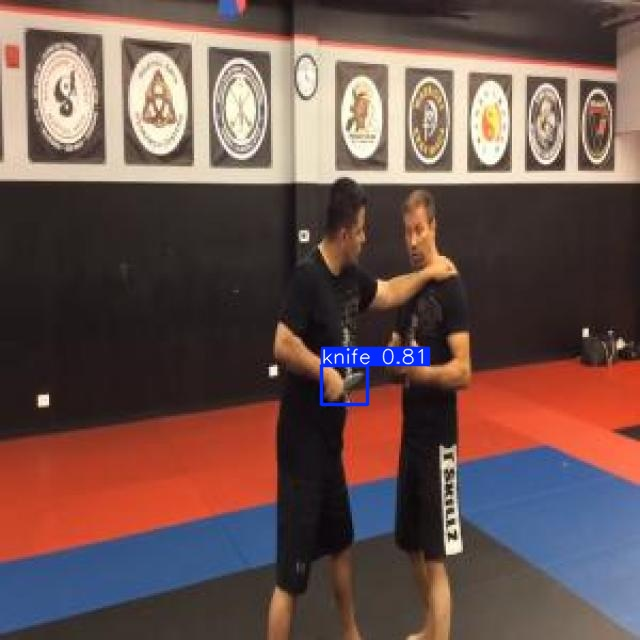

In [ ]:
i = 20
for image in glob.glob("/content/drive/MyDrive/model ml/threat detection/ThreatDetection2.3.0/detected_images/*.jpg"):
    display(Image(filename=image, width=500, height=200))
    i-=1
    if i ==0:
        break